# 🏥 HCAHPS Patient Survey — National Quality of Care Analysis
---

## Project Overview

The **Hospital Consumer Assessment of Healthcare Providers and Systems (HCAHPS)** survey
is a national, standardized instrument that measures patients' perspectives on hospital care.
This project analyzes **national and state-level scores from 2013 to 2022** across 10 measures
covering communication, responsiveness, environment, and overall experience.

---

## Analytical Questions

| # | Question | Focus Area |
|---|----------|------------|
| 1 | Are hospitals improving overall over the past 9 years? | Trend Analysis |
| 2 | Which measures improved the most? | Measure Progress |
| 3 | Where are the persistent low-performance areas? | Opportunity Zones |
| 4 | Did COVID-19 cause a visible dip in patient experience? | Pandemic Impact |
| 5 | Which states and regions consistently outperform others? | Geographic Analysis |
| 6 | Are response rates and survey volumes changing over time? | Data Reliability |
| 7 | Do Composite, Individual, and Global measures improve differently? | Measure Type Analysis |

---

## Dataset Tables

| Table | Description |
|-------|-------------|
| `reports.csv` | Release periods and date ranges |
| `measures.csv` | 10 HCAHPS measures and their types |
| `questions.csv` | Individual survey questions per measure |
| `national_results.csv` | National-level top/middle/bottom-box % per measure per period |
| `state_results.csv` | State-level top/middle/bottom-box % per measure per period |
| `responses.csv` | Facility-level survey counts and response rates |
| `states.csv` | State abbreviations, names, and Census regions |

---

*Analysis performed in Python — Pandas · Matplotlib · Seaborn*

In [1]:
# ============================================================
# IMPORTS & CONFIGURATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# ── Plot Style ───────────────────────────────────────────────
plt.rcParams['figure.figsize']   = (14, 6)
plt.rcParams['figure.dpi']       = 120
plt.rcParams['font.family']      = 'DejaVu Sans'
plt.rcParams['font.size']        = 11
plt.rcParams['axes.titlesize']   = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.3
plt.rcParams['lines.linewidth']  = 2.5
plt.rcParams['lines.markersize'] = 7

# ── Color Palette ────────────────────────────────────────────
PALETTE   = sns.color_palette('tab10', 10)
TOP_COLOR = '#2ecc71'   # green  → top-box (most positive)
MID_COLOR = '#f39c12'   # orange → middle-box
BOT_COLOR = '#e74c3c'   # red    → bottom-box (least positive)

# ── Project Paths ────────────────────────────────────────────
BASE_DIR    = '/home/pharmacy/HCAHPS+Patient+Survey'
DATA_DIR    = os.path.join(BASE_DIR, 'data_tables')
CHARTS_DIR  = os.path.join(BASE_DIR, 'Charts')
NEW_DIR     = os.path.join(BASE_DIR, 'New_Created_Tables')

os.makedirs(CHARTS_DIR, exist_ok=True)
os.makedirs(NEW_DIR,    exist_ok=True)

print("✅ Libraries imported successfully")
print(f"📁 Data directory   : {DATA_DIR}")
print(f"📊 Charts directory : {CHARTS_DIR}")
print(f"💾 New tables dir   : {NEW_DIR}")

✅ Libraries imported successfully
📁 Data directory   : /home/pharmacy/HCAHPS+Patient+Survey/data_tables
📊 Charts directory : /home/pharmacy/HCAHPS+Patient+Survey/Charts
💾 New tables dir   : /home/pharmacy/HCAHPS+Patient+Survey/New_Created_Tables


## 1. Data Loading & Validation

Before any analysis, we load all seven CSV tables into pandas DataFrames
and perform basic validation checks on each one:

- **Shape** — how many rows and columns?
- **Data types** — are columns parsed correctly?
- **Missing values** — any nulls that need attention?
- **Preview** — first few rows to confirm structure

This step ensures we have a clean, reliable foundation before
drawing any conclusions from the data.

In [2]:
# ============================================================
# DATA LOADING & VALIDATION
# ============================================================

# ── Load all tables ──────────────────────────────────────────
reports         = pd.read_csv(os.path.join(DATA_DIR, 'reports.csv'))
measures        = pd.read_csv(os.path.join(DATA_DIR, 'measures.csv'))
questions       = pd.read_csv(os.path.join(DATA_DIR, 'questions.csv'))
national_results= pd.read_csv(os.path.join(DATA_DIR, 'national_results.csv'))
state_results   = pd.read_csv(os.path.join(DATA_DIR, 'state_results.csv'))
responses       = pd.read_csv(os.path.join(DATA_DIR, 'responses.csv'))
states          = pd.read_csv(os.path.join(DATA_DIR, 'states.csv'))

# ── Validation helper ────────────────────────────────────────
def validate_table(name, df):
    print(f"\n{'='*55}")
    print(f"  📋 {name}")
    print(f"{'='*55}")
    print(f"  Shape            : {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"  Columns          : {list(df.columns)}")
    print(f"  Missing values   : {df.isnull().sum().sum():,} total nulls")
    print(f"\n  --- First 2 rows preview ---")
    display(df.head(2))

# ── Run validation on all tables ─────────────────────────────
tables = {
    'reports'         : reports,
    'measures'        : measures,
    'questions'       : questions,
    'national_results': national_results,
    'state_results'   : state_results,
    'responses'       : responses,
    'states'          : states,
}

for name, df in tables.items():
    validate_table(name, df)

print(f"\n{'='*55}")
print("✅ All 7 tables loaded and validated successfully")
print(f"{'='*55}")


  📋 reports
  Shape            : 9 rows × 3 columns
  Columns          : ['Release Period', 'Start Date', 'End Date']
  Missing values   : 0 total nulls

  --- First 2 rows preview ---


,Release Period,Start Date,End Date
0,07_2015,2013-10-01,2014-09-30
1,07_2016,2014-10-01,2015-09-30



  📋 measures
  Shape            : 10 rows × 3 columns
  Columns          : ['Measure ID', 'Measure', 'Type']
  Missing values   : 0 total nulls

  --- First 2 rows preview ---


,Measure ID,Measure,Type
0,H_COMP_1,Communication with Nurses,Composite Measure
1,H_COMP_2,Communication with Doctors,Composite Measure



  📋 questions
  Shape            : 19 rows × 6 columns
  Columns          : ['Question Num', 'Measure ID', 'Question', 'Bottom-box Answer', 'Middle-box Answer', 'Top-box Answer']
  Missing values   : 2 total nulls

  --- First 2 rows preview ---


...


  📋 responses
  Shape            : 43,219 rows × 5 columns
  Columns          : ['Release Period', 'State', 'Facility ID', 'Completed Surveys', 'Response Rate (%)']
  Missing values   : 0 total nulls

  --- First 2 rows preview ---


,Release Period,State,Facility ID,Completed Surveys,Response Rate (%)
0,07_2015,AL,10001,300 or more,27
1,07_2015,AL,10005,300 or more,37



  📋 states
  Shape            : 51 rows × 3 columns
  Columns          : ['State', 'State Name', 'Region']
  Missing values   : 0 total nulls

  --- First 2 rows preview ---


,State,State Name,Region
0,AK,Alaska,Pacific
1,AL,Alabama,East South Central



✅ All 7 tables loaded and validated successfully


## 2. Data Cleaning & Preprocessing

Based on the validation step, we identified the following issues to address:

| Table | Issue | Action |
|-------|-------|--------|
| `reports` | Date columns stored as strings | Convert to datetime |
| `national_results` | Release Period stored as string | Extract numeric year |
| `state_results` | Release Period stored as string | Extract numeric year |
| `responses` | `Completed Surveys` is categorical text | Keep as-is (ordinal category) |
| `responses` | `Response Rate (%)` contains "Not Available" | Replace with NaN, cast to float |
| `questions` | 2 nulls in `Middle-box Answer` | Expected — H_COMP_6 has no middle box |

After cleaning, we will merge the core analytical tables into
two master DataFrames:

- **`national_df`** — national results enriched with measure names, types, and report dates
- **`state_df`** — state results enriched with measure names, types, state names, and regions

In [3]:
# ============================================================
# DATA CLEANING & PREPROCESSING
# ============================================================

# ── 1. reports — convert dates ───────────────────────────────
reports['Start Date'] = pd.to_datetime(reports['Start Date'])
reports['End Date']   = pd.to_datetime(reports['End Date'])
reports['Year']       = reports['Release Period'].str.split('_').str[1].astype(int)

print("✅ reports — dates converted, Year column added")
print(reports.dtypes)
print()

# ── 2. national_results — extract year ───────────────────────
national_results['Year'] = (national_results['Release Period']
                             .str.split('_').str[1].astype(int))

print("✅ national_results — Year column added")
print()

# ── 3. state_results — extract year ──────────────────────────
state_results['Year'] = (state_results['Release Period']
                          .str.split('_').str[1].astype(int))

print("✅ state_results — Year column added")
print()

# ── 4. responses — fix mixed-type columns ────────────────────
# Response Rate (%): replace 'Not Available' with NaN then cast to float
responses['Response Rate (%)'] = pd.to_numeric(
    responses['Response Rate (%)'].replace('Not Available', np.nan),
    errors='coerce'
)

# Completed Surveys: convert to ordered categorical
survey_order = ['Fewer than 100', 'Between 100 and 299', '300 or more', 'Not Available']
responses['Completed Surveys'] = pd.Categorical(
    responses['Completed Surveys'],
    categories=survey_order,
    ordered=True
)

# Extract year
responses['Year'] = (responses['Release Period']
                      .str.split('_').str[1].astype(int))

print("✅ responses — Response Rate cast to float, Completed Surveys categorized")
print(f"   Nulls in Response Rate: {responses['Response Rate (%)'].isnull().sum():,}")
print()

# ── 5. Build national_df (master national table) ─────────────
national_df = (national_results
               .merge(measures, on='Measure ID', how='left')
               .merge(reports[['Release Period','Year','Start Date','End Date']],
                      on='Release Period', how='left'))

# Rename for clarity
national_df.rename(columns={
    'Bottom-box Percentage' : 'Bottom_pct',
    'Middle-box Percentage' : 'Middle_pct',
    'Top-box Percentage'    : 'Top_pct',
    'Measure ID'            : 'Measure_ID',
    'Release Period'        : 'Release_Period',
    'Start Date'            : 'Start_Date',
    'End Date'              : 'End_Date',
}, inplace=True)

print("✅ national_df created")
print(f"   Shape : {national_df.shape}")
display(national_df.head(3))
print()

# ── 6. Build state_df (master state table) ───────────────────
state_df = (state_results
            .merge(measures, on='Measure ID', how='left')
            .merge(states,   on='State',      how='left')
            .merge(reports[['Release Period','Year','Start Date','End Date']],
                   on='Release Period', how='left'))

state_df.rename(columns={
    'Bottom-box Percentage' : 'Bottom_pct',
    'Middle-box Percentage' : 'Middle_pct',
    'Top-box Percentage'    : 'Top_pct',
    'Measure ID'            : 'Measure_ID',
    'Release Period'        : 'Release_Period',
    'Start Date'            : 'Start_Date',
    'End Date'              : 'End_Date',
    'State Name'            : 'State_Name',
}, inplace=True)

print("✅ state_df created")
print(f"   Shape : {state_df.shape}")
display(state_df.head(3))
print()

print("="*55)
print("✅ All cleaning & merging completed successfully")
print("="*55)

✅ reports — dates converted, Year column added
Release Period               str
Start Date        datetime64[us]
End Date          datetime64[us]
Year                       int64
dtype: object

✅ national_results — Year column added

✅ state_results — Year column added

✅ responses — Response Rate cast to float, Completed Surveys categorized
   Nulls in Response Rate: 5,774

✅ national_df created
   Shape : (90, 11)


,Release_Period,Measure_ID,Bottom_pct,Middle_pct,Top_pct,Year_x,Measure,Type,Year_y,Start_Date,End_Date
0,07_2015,H_CLEAN_HSP,8,18,74,2015,Cleanliness of Hospital Environment,Individual Item,2015,2013-10-01,2014-09-30
1,07_2015,H_COMP_1,4,17,79,2015,Communication with Nurses,Composite Measure,2015,2013-10-01,2014-09-30
2,07_2015,H_COMP_2,4,14,82,2015,Communication with Doctors,Composite Measure,2015,2013-10-01,2014-09-30



✅ state_df created
   Shape : (4580, 14)


,Release_Period,State,Measure_ID,Bottom_pct,Middle_pct,Top_pct,Year_x,Measure,Type,State_Name,Region,Year_y,Start_Date,End_Date
0,07_2015,AK,H_CLEAN_HSP,8,22,70,2015,Cleanliness of Hospital Environment,Individual Item,Alaska,Pacific,2015,2013-10-01,2014-09-30
1,07_2015,AK,H_COMP_1,9,17,74,2015,Communication with Nurses,Composite Measure,Alaska,Pacific,2015,2013-10-01,2014-09-30
2,07_2015,AK,H_COMP_2,10,15,75,2015,Communication with Doctors,Composite Measure,Alaska,Pacific,2015,2013-10-01,2014-09-30



✅ All cleaning & merging completed successfully


## 3. Exploratory Data Analysis (EDA)

Before diving into the specific analytical questions, we explore
the data broadly to understand its structure and distributions.

This section covers:

- **Column cleanup** — drop duplicate Year columns from merges, keep one clean `Year`
- **Measure distribution** — how many Composite, Individual, and Global measures?
- **Score distribution** — what is the overall spread of Top-box percentages nationally?
- **Period coverage** — confirm all 9 release periods are present and balanced
- **Response rate overview** — what is the national average response rate per year?

These findings set the context for all subsequent analyses.

✅ national_df — Year column already clean
✅ state_df — Year column already clean

   national_df columns : ['Release_Period', 'Measure_ID', 'Bottom_pct', 'Middle_pct', 'Top_pct', 'Year', 'Measure', 'Type', 'Start_Date', 'End_Date']
   state_df columns    : ['Release_Period', 'State', 'Measure_ID', 'Bottom_pct', 'Middle_pct', 'Top_pct', 'Year', 'Measure', 'Type', 'State_Name', 'Region', 'Start_Date', 'End_Date']

📊 Measure Type Distribution
────────────────────────────────────────
Type
Composite Measure    6
Individual Item      2
Global Item          2

📅 Release Periods in national_df
────────────────────────────────────────
Year
2015    10
2016    10
2017    10
2018    10
2019    10
2020    10
2021    10
2022    10
2023    10

   Total periods : 9
   Total measures: 10

📈 National Top-box % — Summary Statistics
────────────────────────────────────────
count    90.0
mean     71.4
std       9.6
min      51.0
25%      65.0
50%      72.0
75%      80.0
max      87.0

📋 Average Response Ra

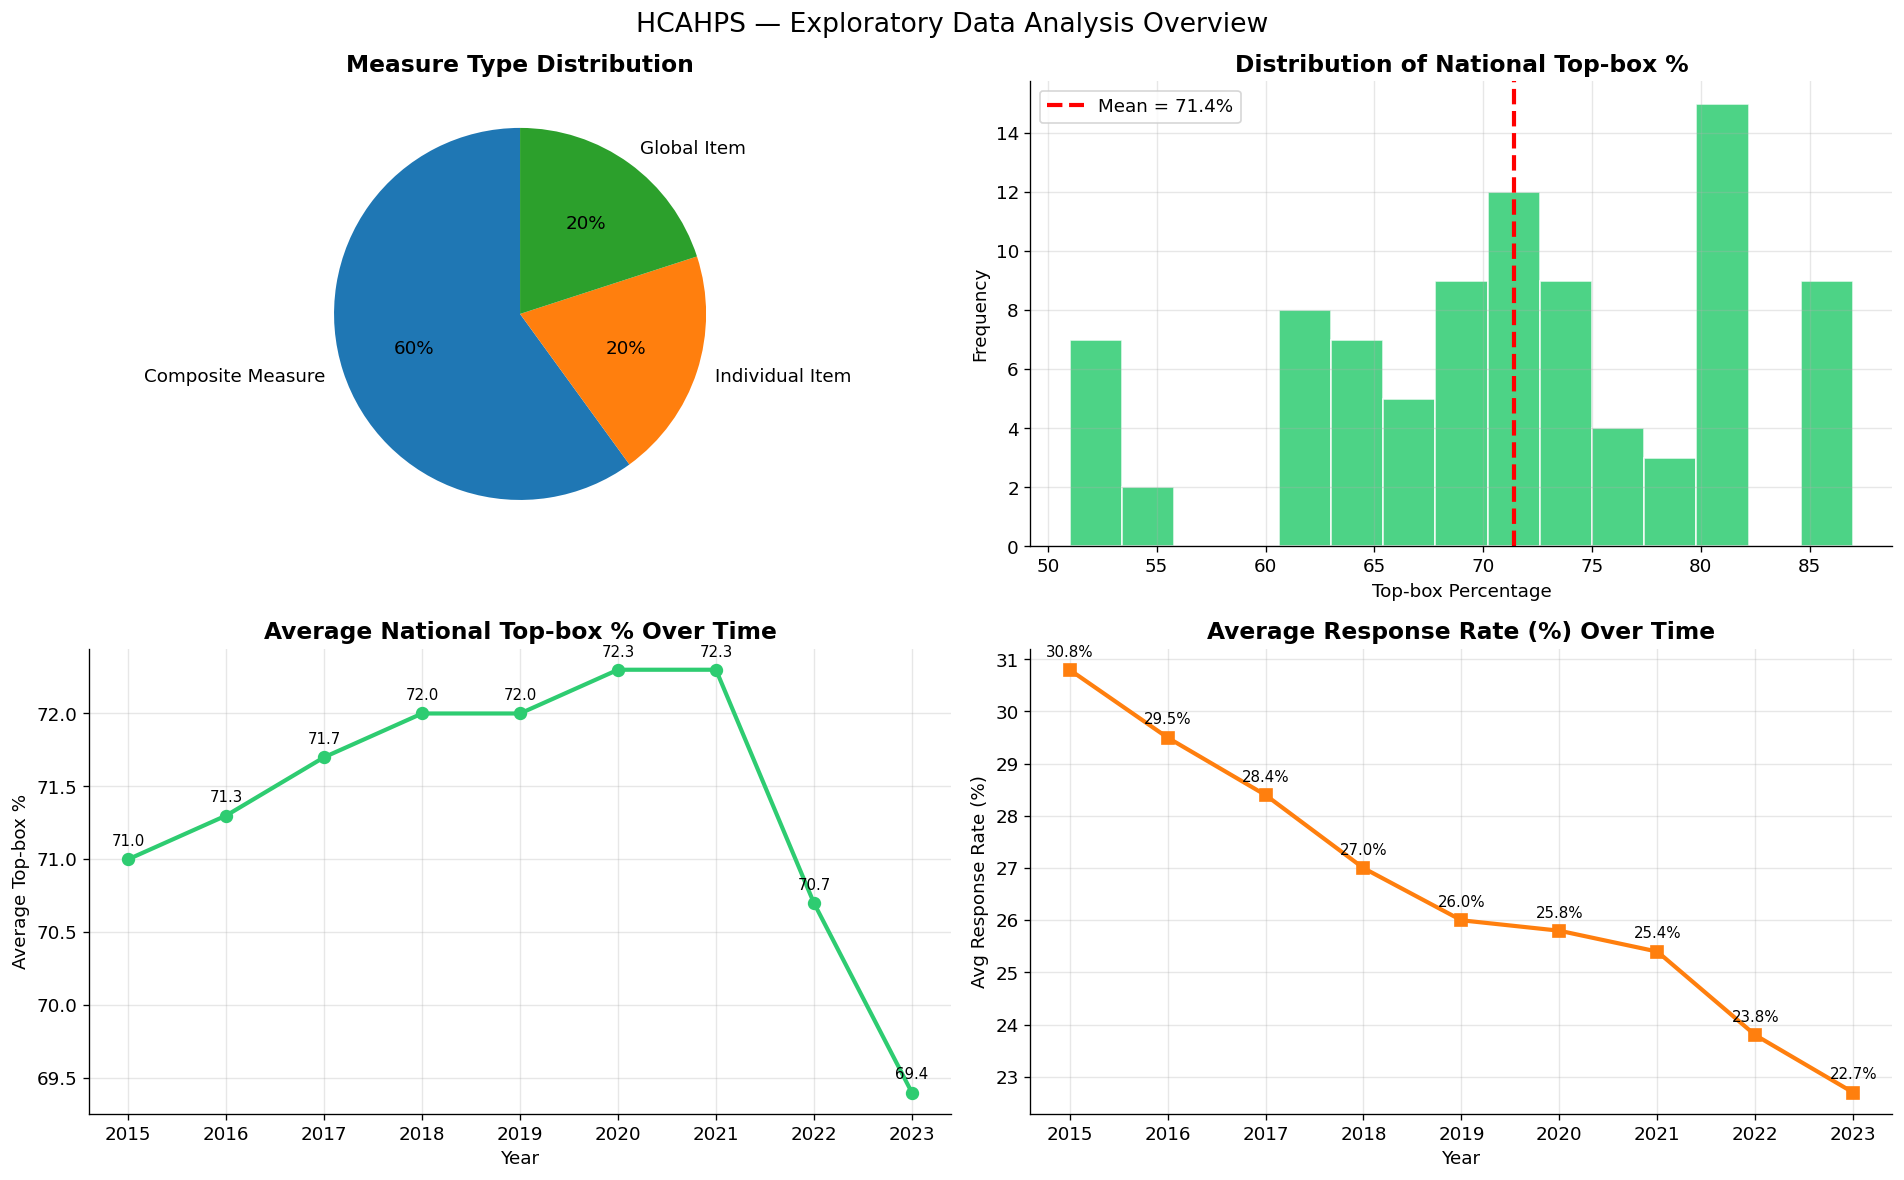

💾 Chart saved → /home/pharmacy/HCAHPS+Patient+Survey/Charts/01_EDA_Overview.png


In [6]:
# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# ── 1. Check and fix duplicate Year columns ──────────────────
def fix_year_columns(df, name):
    cols = list(df.columns)
    if 'Year_x' in cols and 'Year_y' in cols:
        df.drop(columns=['Year_y'], inplace=True)
        df.rename(columns={'Year_x': 'Year'}, inplace=True)
        print(f"✅ {name} — Year_x/Year_y fixed → single Year column")
    elif 'Year' in cols:
        print(f"✅ {name} — Year column already clean")
    else:
        print(f"⚠️  {name} — no Year column found, check merge")

fix_year_columns(national_df, 'national_df')
fix_year_columns(state_df,    'state_df')
print(f"\n   national_df columns : {list(national_df.columns)}")
print(f"   state_df columns    : {list(state_df.columns)}")
print()

# ── 2. Measure type distribution ─────────────────────────────
print("📊 Measure Type Distribution")
print("─"*40)
print(measures['Type'].value_counts().to_string())
print()

# ── 3. Period coverage ───────────────────────────────────────
print("📅 Release Periods in national_df")
print("─"*40)
period_counts = national_df.groupby('Year')['Measure_ID'].count()
print(period_counts.to_string())
print(f"\n   Total periods : {national_df['Year'].nunique()}")
print(f"   Total measures: {national_df['Measure_ID'].nunique()}")
print()

# ── 4. Top-box score distribution ────────────────────────────
print("📈 National Top-box % — Summary Statistics")
print("─"*40)
print(national_df['Top_pct'].describe().round(1).to_string())
print()

# ── 5. Response rate overview ────────────────────────────────
print("📋 Average Response Rate (%) by Year")
print("─"*40)
rr_by_year = (responses.groupby('Year')['Response Rate (%)']
              .mean().round(1))
print(rr_by_year.to_string())
print()

# ── 6. EDA Visualization — 2×2 dashboard ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('HCAHPS — Exploratory Data Analysis Overview', fontsize=16)

# ── 6a. Measure type pie ──────────────────────────────────────
ax = axes[0, 0]
type_counts = measures['Type'].value_counts()
ax.pie(type_counts.values,
       labels=type_counts.index,
       autopct='%1.0f%%',
       colors=[PALETTE[0], PALETTE[1], PALETTE[2]],
       startangle=90)
ax.set_title('Measure Type Distribution')

# ── 6b. Top-box % distribution histogram ─────────────────────
ax = axes[0, 1]
ax.hist(national_df['Top_pct'], bins=15,
        color=TOP_COLOR, edgecolor='white', alpha=0.85)
ax.set_title('Distribution of National Top-box %')
ax.set_xlabel('Top-box Percentage')
ax.set_ylabel('Frequency')
ax.axvline(national_df['Top_pct'].mean(), color='red',
           linestyle='--', label=f"Mean = {national_df['Top_pct'].mean():.1f}%")
ax.legend()

# ── 6c. Average Top-box % per year (all measures) ────────────
ax = axes[1, 0]
avg_by_year = national_df.groupby('Year')['Top_pct'].mean()
ax.plot(avg_by_year.index, avg_by_year.values,
        marker='o', color=TOP_COLOR)
ax.set_title('Average National Top-box % Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Average Top-box %')
ax.set_xticks(avg_by_year.index)
for x, y in zip(avg_by_year.index, avg_by_year.values):
    ax.annotate(f'{y:.1f}', (x, y),
                textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9)

# ── 6d. Average response rate per year ───────────────────────
ax = axes[1, 1]
ax.plot(rr_by_year.index, rr_by_year.values,
        marker='s', color=PALETTE[1])
ax.set_title('Average Response Rate (%) Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Avg Response Rate (%)')
ax.set_xticks(rr_by_year.index)
for x, y in zip(rr_by_year.index, rr_by_year.values):
    ax.annotate(f'{y:.1f}%', (x, y),
                textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9)

plt.tight_layout()
chart_path = os.path.join(CHARTS_DIR, '01_EDA_Overview.png')
plt.savefig(chart_path, bbox_inches='tight')
plt.show()
print(f"💾 Chart saved → {chart_path}")

## 4. Q1 — Overall National Trend: Are Hospitals Improving?

### Question
Have hospitals made measurable improvements in patient experience
over the 9-year period from 2015 to 2023?

### Approach
We analyze the **national Top-box percentage** for each of the
10 HCAHPS measures across all 9 release periods.

- Plot each measure's Top-box % trajectory over time
- Overlay the overall average trend line
- Highlight the COVID-19 pandemic window (2020–2021)
- Calculate the net change (2015 → 2023) per measure

### Why Top-box?
The Top-box percentage (most positive response) is the primary
metric used by CMS to benchmark hospital performance.
A rising Top-box % directly reflects improved patient experience.

📈 Net Change in Top-box % (2015 → 2023)
──────────────────────────────────────────────────
  ▼ Communication about Medicines            -4%
  ▼ Communication with Doctors               -3%
  ▼ Responsiveness of Hospital Staff         -3%
  ▼ Cleanliness of Hospital Environment      -2%
  ▼ Willingness to Recommend the Hospital    -2%
  ▼ Care Transition                          -1%
  ▼ Overall Hospital Rating                  -1%
  ▼ Communication with Nurses                +0%
  ▼ Discharge Information                    +0%
  ▼ Quietness of Hospital Environment        +0%

  Overall average change : -1.6%



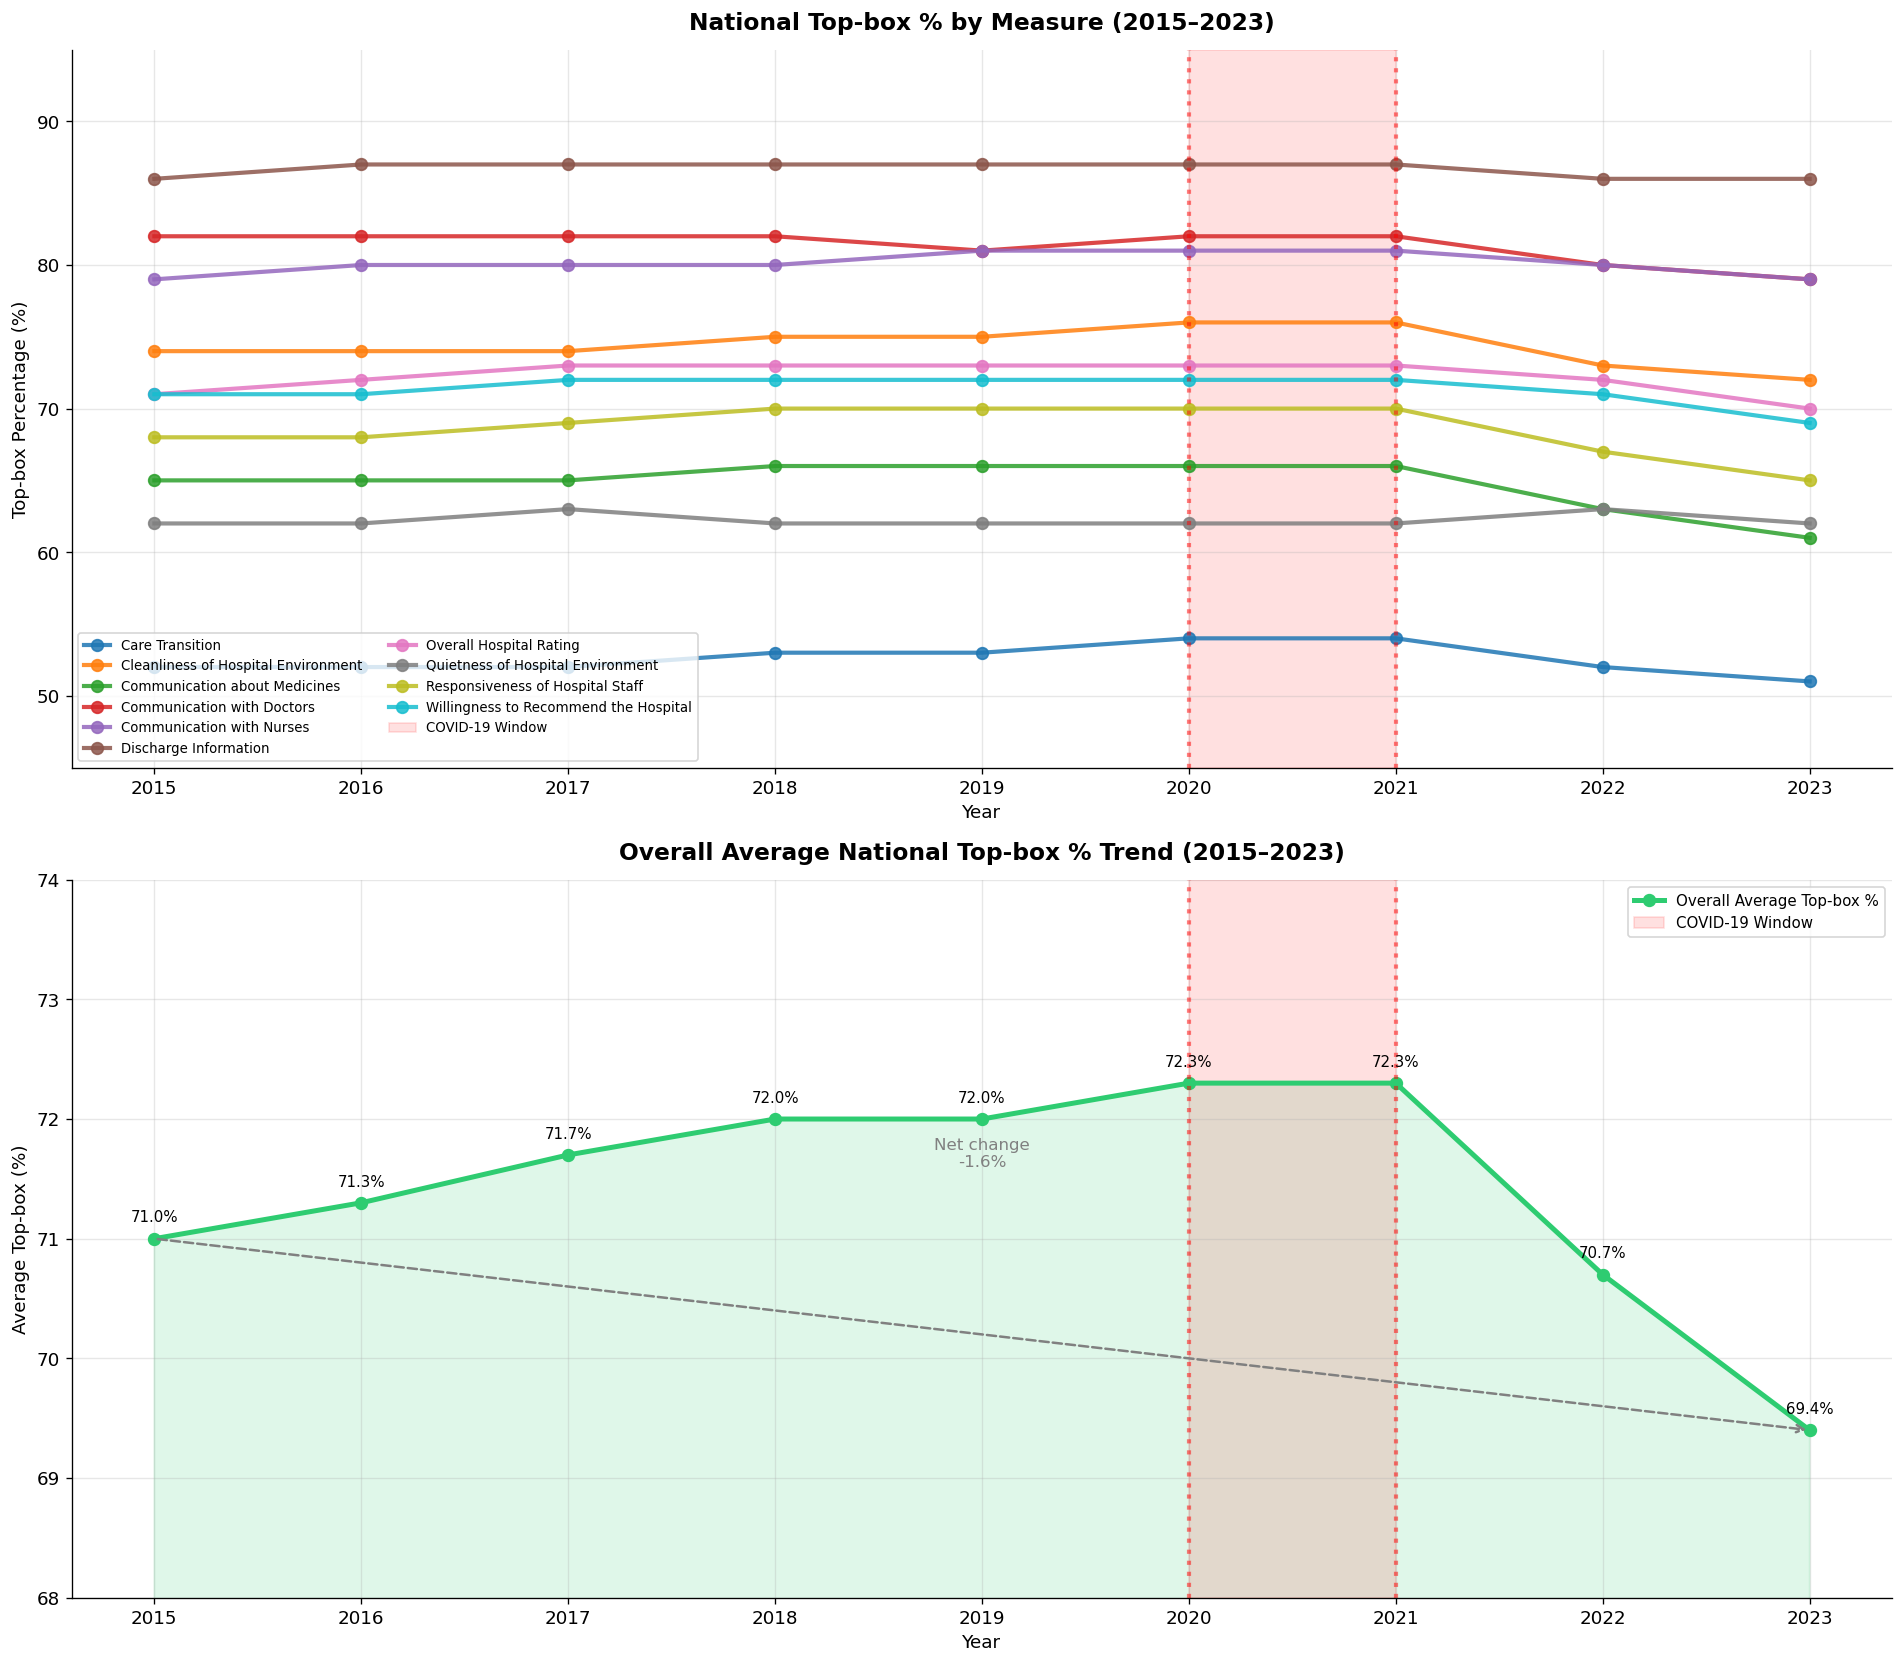

💾 Chart saved → /home/pharmacy/HCAHPS+Patient+Survey/Charts/02_Q1_National_Trend.png


In [7]:
# ============================================================
# Q1 — OVERALL NATIONAL TREND ANALYSIS
# ============================================================

# ── 1. Pivot: measures as columns, years as rows ──────────────
trend_pivot = (national_df
               .pivot_table(index='Year',
                            columns='Measure',
                            values='Top_pct'))

# ── 2. Net change per measure (2015 → 2023) ──────────────────
net_change = (trend_pivot.loc[2023] - trend_pivot.loc[2015]).sort_values()

print("📈 Net Change in Top-box % (2015 → 2023)")
print("─"*50)
for measure, change in net_change.items():
    arrow = "▲" if change > 0 else "▼"
    print(f"  {arrow} {measure:<40} {change:+.0f}%")
print()

overall_net = national_df.groupby('Year')['Top_pct'].mean()
overall_change = overall_net.loc[2023] - overall_net.loc[2015]
print(f"  Overall average change : {overall_change:+.1f}%")
print()

# ── 3. Main trend chart — each measure over time ─────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# ── 3a. Individual measure trends ────────────────────────────
ax = axes[0]
for i, measure in enumerate(trend_pivot.columns):
    ax.plot(trend_pivot.index,
            trend_pivot[measure],
            marker='o',
            color=PALETTE[i],
            label=measure,
            alpha=0.85)

# COVID window shading
ax.axvspan(2020, 2021, alpha=0.12, color='red', label='COVID-19 Window')
ax.axvline(2020, color='red', linestyle=':', alpha=0.5)
ax.axvline(2021, color='red', linestyle=':', alpha=0.5)

ax.set_title('National Top-box % by Measure (2015–2023)', pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Top-box Percentage (%)')
ax.set_xticks(trend_pivot.index)
ax.legend(loc='lower left', fontsize=8, ncol=2)
ax.set_ylim(45, 95)

# ── 3b. Overall average trend with net change annotation ──────
ax = axes[1]
avg_trend = national_df.groupby('Year')['Top_pct'].mean()

ax.fill_between(avg_trend.index, avg_trend.values,
                alpha=0.15, color=TOP_COLOR)
ax.plot(avg_trend.index, avg_trend.values,
        marker='o', color=TOP_COLOR, linewidth=3,
        label='Overall Average Top-box %')

# COVID window
ax.axvspan(2020, 2021, alpha=0.12, color='red', label='COVID-19 Window')
ax.axvline(2020, color='red', linestyle=':', alpha=0.5)
ax.axvline(2021, color='red', linestyle=':', alpha=0.5)

# Annotate each point
for x, y in zip(avg_trend.index, avg_trend.values):
    ax.annotate(f'{y:.1f}%', (x, y),
                textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)

# Annotate net change arrow
ax.annotate('',
            xy=(2023, avg_trend.loc[2023]),
            xytext=(2015, avg_trend.loc[2015]),
            arrowprops=dict(arrowstyle='->', color='gray',
                            lw=1.5, linestyle='dashed'))
ax.annotate(f'Net change\n{overall_change:+.1f}%',
            xy=(2019, 71.6),
            fontsize=10, color='gray', ha='center')

ax.set_title('Overall Average National Top-box % Trend (2015–2023)', pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Average Top-box (%)')
ax.set_xticks(avg_trend.index)
ax.set_ylim(68, 74)
ax.legend(fontsize=9)

plt.tight_layout()
chart_path = os.path.join(CHARTS_DIR, '02_Q1_National_Trend.png')
plt.savefig(chart_path, bbox_inches='tight')
plt.show()
print(f"💾 Chart saved → {chart_path}")

## 5. Q2 — Measure-by-Measure Progress: Where Did Hospitals Improve Most?

### Question
Are there specific HCAHPS measures where hospitals have made
more progress than others over the 9-year period?

### Approach
We examine each measure individually to understand:

- The **absolute Top-box % change** from 2015 to 2023
- The **peak year** for each measure
- The **post-peak decline** — how much ground was lost after the peak
- A **bar chart ranked by net change** to visually compare all measures

### Why this matters
Even in an overall declining trend, some measures may show
resilience or relative improvement — these are the areas where
hospital interventions appear to be working and should be reinforced.
Conversely, the steepest declines signal where urgent action is needed.

📊 Measure-by-Measure Summary (2015 → 2023)
───────────────────────────────────────────────────────────────────────────


,Measure,Start (2015),End (2023),Peak %,Peak Year,Net Change,Post-Peak Drop
0,Communication with Nurses,79.0,79.0,81.0,2019,0.0,-2.0
1,Discharge Information,86.0,86.0,87.0,2016,0.0,-1.0
2,Quietness of Hospital Environment,62.0,62.0,63.0,2017,0.0,-1.0
3,Care Transition,52.0,51.0,54.0,2020,-1.0,-3.0
4,Overall Hospital Rating,71.0,70.0,73.0,2017,-1.0,-3.0
5,Cleanliness of Hospital Environment,74.0,72.0,76.0,2020,-2.0,-4.0
6,Willingness to Recommend the Hospital,71.0,69.0,72.0,2017,-2.0,-3.0
7,Communication with Doctors,82.0,79.0,82.0,2015,-3.0,-3.0
8,Responsiveness of Hospital Staff,68.0,65.0,70.0,2018,-3.0,-5.0
9,Communication about Medicines,65.0,61.0,66.0,2018,-4.0,-5.0


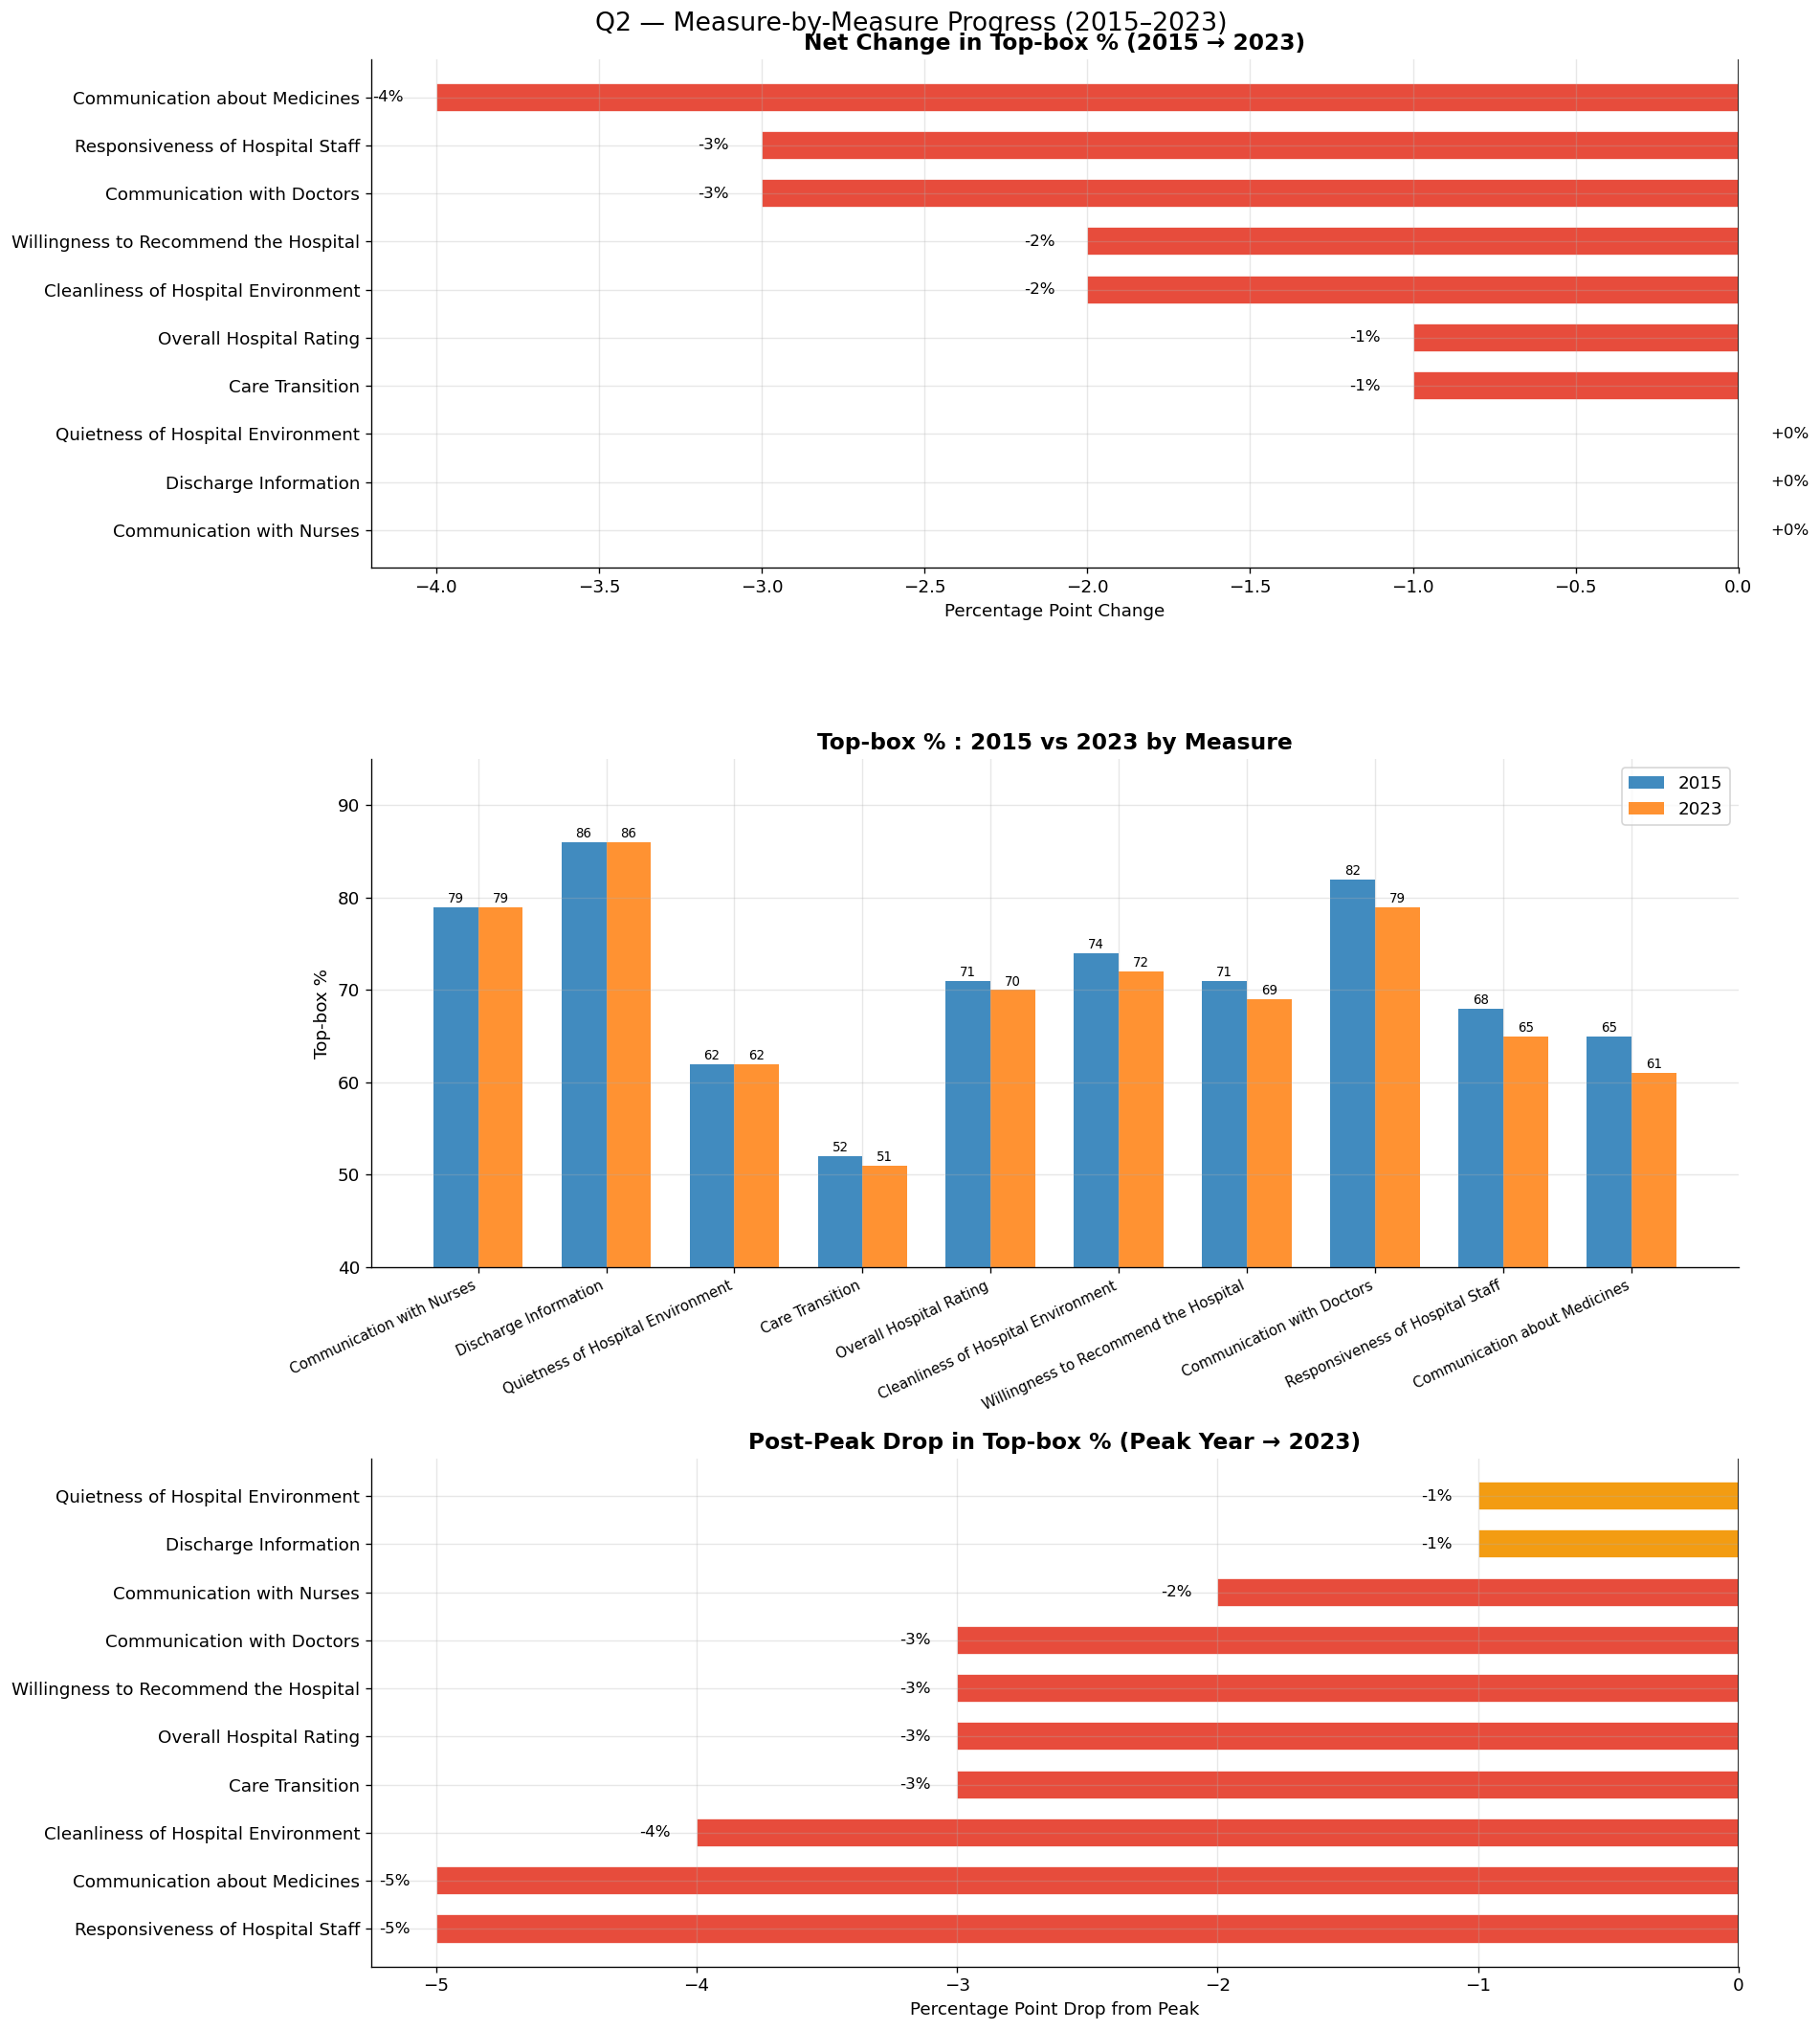

💾 Chart saved → /home/pharmacy/HCAHPS+Patient+Survey/Charts/03_Q2_Measure_Progress.png


In [8]:
# ============================================================
# Q2 — MEASURE-BY-MEASURE PROGRESS
# ============================================================

# ── 1. Build measure summary table ───────────────────────────
measure_summary = []

for measure in trend_pivot.columns:
    series      = trend_pivot[measure].dropna()
    start_val   = series.loc[2015]
    end_val     = series.loc[2023]
    peak_val    = series.max()
    peak_year   = series.idxmax()
    post_decline= peak_val - end_val
    net_change  = end_val - start_val

    measure_summary.append({
        'Measure'      : measure,
        'Start (2015)' : start_val,
        'End (2023)'   : end_val,
        'Peak %'       : peak_val,
        'Peak Year'    : peak_year,
        'Net Change'   : net_change,
        'Post-Peak Drop': -post_decline,
    })

summary_df = (pd.DataFrame(measure_summary)
              .sort_values('Net Change', ascending=False)
              .reset_index(drop=True))

print("📊 Measure-by-Measure Summary (2015 → 2023)")
print("─"*75)
display(summary_df.round(1))
print()

# ── 2. Visualization — 3 panels ──────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 18))
fig.suptitle('Q2 — Measure-by-Measure Progress (2015–2023)', fontsize=16)

# ── 2a. Net change bar chart ──────────────────────────────────
ax = axes[0]
colors = [TOP_COLOR if x >= 0 else BOT_COLOR
          for x in summary_df['Net Change']]
bars = ax.barh(summary_df['Measure'],
               summary_df['Net Change'],
               color=colors, edgecolor='white', height=0.6)

ax.axvline(0, color='black', linewidth=1)
ax.set_title('Net Change in Top-box % (2015 → 2023)')
ax.set_xlabel('Percentage Point Change')

for bar, val in zip(bars, summary_df['Net Change']):
    offset = 0.1 if val >= 0 else -0.1
    ha     = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}%', va='center', ha=ha, fontsize=10)

# ── 2b. Start vs End grouped bar ─────────────────────────────
ax = axes[1]
x      = np.arange(len(summary_df))
width  = 0.35

b1 = ax.bar(x - width/2, summary_df['Start (2015)'],
            width, label='2015', color=PALETTE[0], alpha=0.85)
b2 = ax.bar(x + width/2, summary_df['End (2023)'],
            width, label='2023', color=PALETTE[1], alpha=0.85)

ax.set_title('Top-box % : 2015 vs 2023 by Measure')
ax.set_ylabel('Top-box %')
ax.set_xticks(x)
ax.set_xticklabels(summary_df['Measure'],
                   rotation=25, ha='right', fontsize=9)
ax.legend()
ax.set_ylim(40, 95)

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.0f}',
            ha='center', fontsize=8)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.0f}',
            ha='center', fontsize=8)

# ── 2c. Post-peak drop bar chart ─────────────────────────────
ax = axes[2]
drop_df = summary_df.sort_values('Post-Peak Drop')
colors2 = [BOT_COLOR if x < -1 else MID_COLOR
           for x in drop_df['Post-Peak Drop']]

bars2 = ax.barh(drop_df['Measure'],
                drop_df['Post-Peak Drop'],
                color=colors2, edgecolor='white', height=0.6)

ax.axvline(0, color='black', linewidth=1)
ax.set_title('Post-Peak Drop in Top-box % (Peak Year → 2023)')
ax.set_xlabel('Percentage Point Drop from Peak')

for bar, val in zip(bars2, drop_df['Post-Peak Drop']):
    offset = -0.1
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}%', va='center', ha='right', fontsize=10)

plt.tight_layout()
chart_path = os.path.join(CHARTS_DIR, '03_Q2_Measure_Progress.png')
plt.savefig(chart_path, bbox_inches='tight')
plt.show()
print(f"💾 Chart saved → {chart_path}")

## 6. Q3 — Persistent Low-Performance Areas: Where Are Hospitals Still Struggling?

### Question
Which HCAHPS measures consistently score the lowest across all 9 years,
representing the greatest opportunities for improvement?

### Approach
We identify opportunity areas using three lenses:

- **Absolute level** — which measures have the lowest average Top-box %
  across all years? (chronic underperformers)
- **Bottom-box burden** — which measures carry the highest percentage
  of the most negative patient responses?
- **Heatmap** — a year × measure matrix showing the full picture
  of where scores are low and whether they are getting worse

### Why this matters
A measure can decline from a high baseline and still be acceptable.
What is truly alarming is a measure that is **both low and declining** —
these are the urgent intervention targets for hospital leadership.

📊 Average Top-box & Bottom-box % Across All Years
───────────────────────────────────────────────────────


,Top_pct,Bottom_pct
Measure,,
Care Transition,52.6,5.2
Quietness of Hospital Environment,62.2,9.3
Communication about Medicines,64.8,17.8
Responsiveness of Hospital Staff,68.6,8.8
Willingness to Recommend the Hospital,71.3,5.2
Overall Hospital Rating,72.2,7.8
Cleanliness of Hospital Environment,74.3,8.0
Communication with Nurses,80.1,4.2
Communication with Doctors,81.3,4.4



⚠️  National Average Top-box % : 71.4%
   Measures BELOW average (5):
───────────────────────────────────────────────────────
   ▼ Care Transition                            52.6%  (gap: -18.8pp)
   ▼ Quietness of Hospital Environment          62.2%  (gap: -9.2pp)
   ▼ Communication about Medicines              64.8%  (gap: -6.6pp)
   ▼ Responsiveness of Hospital Staff           68.6%  (gap: -2.8pp)
   ▼ Willingness to Recommend the Hospital      71.3%  (gap: -0.1pp)



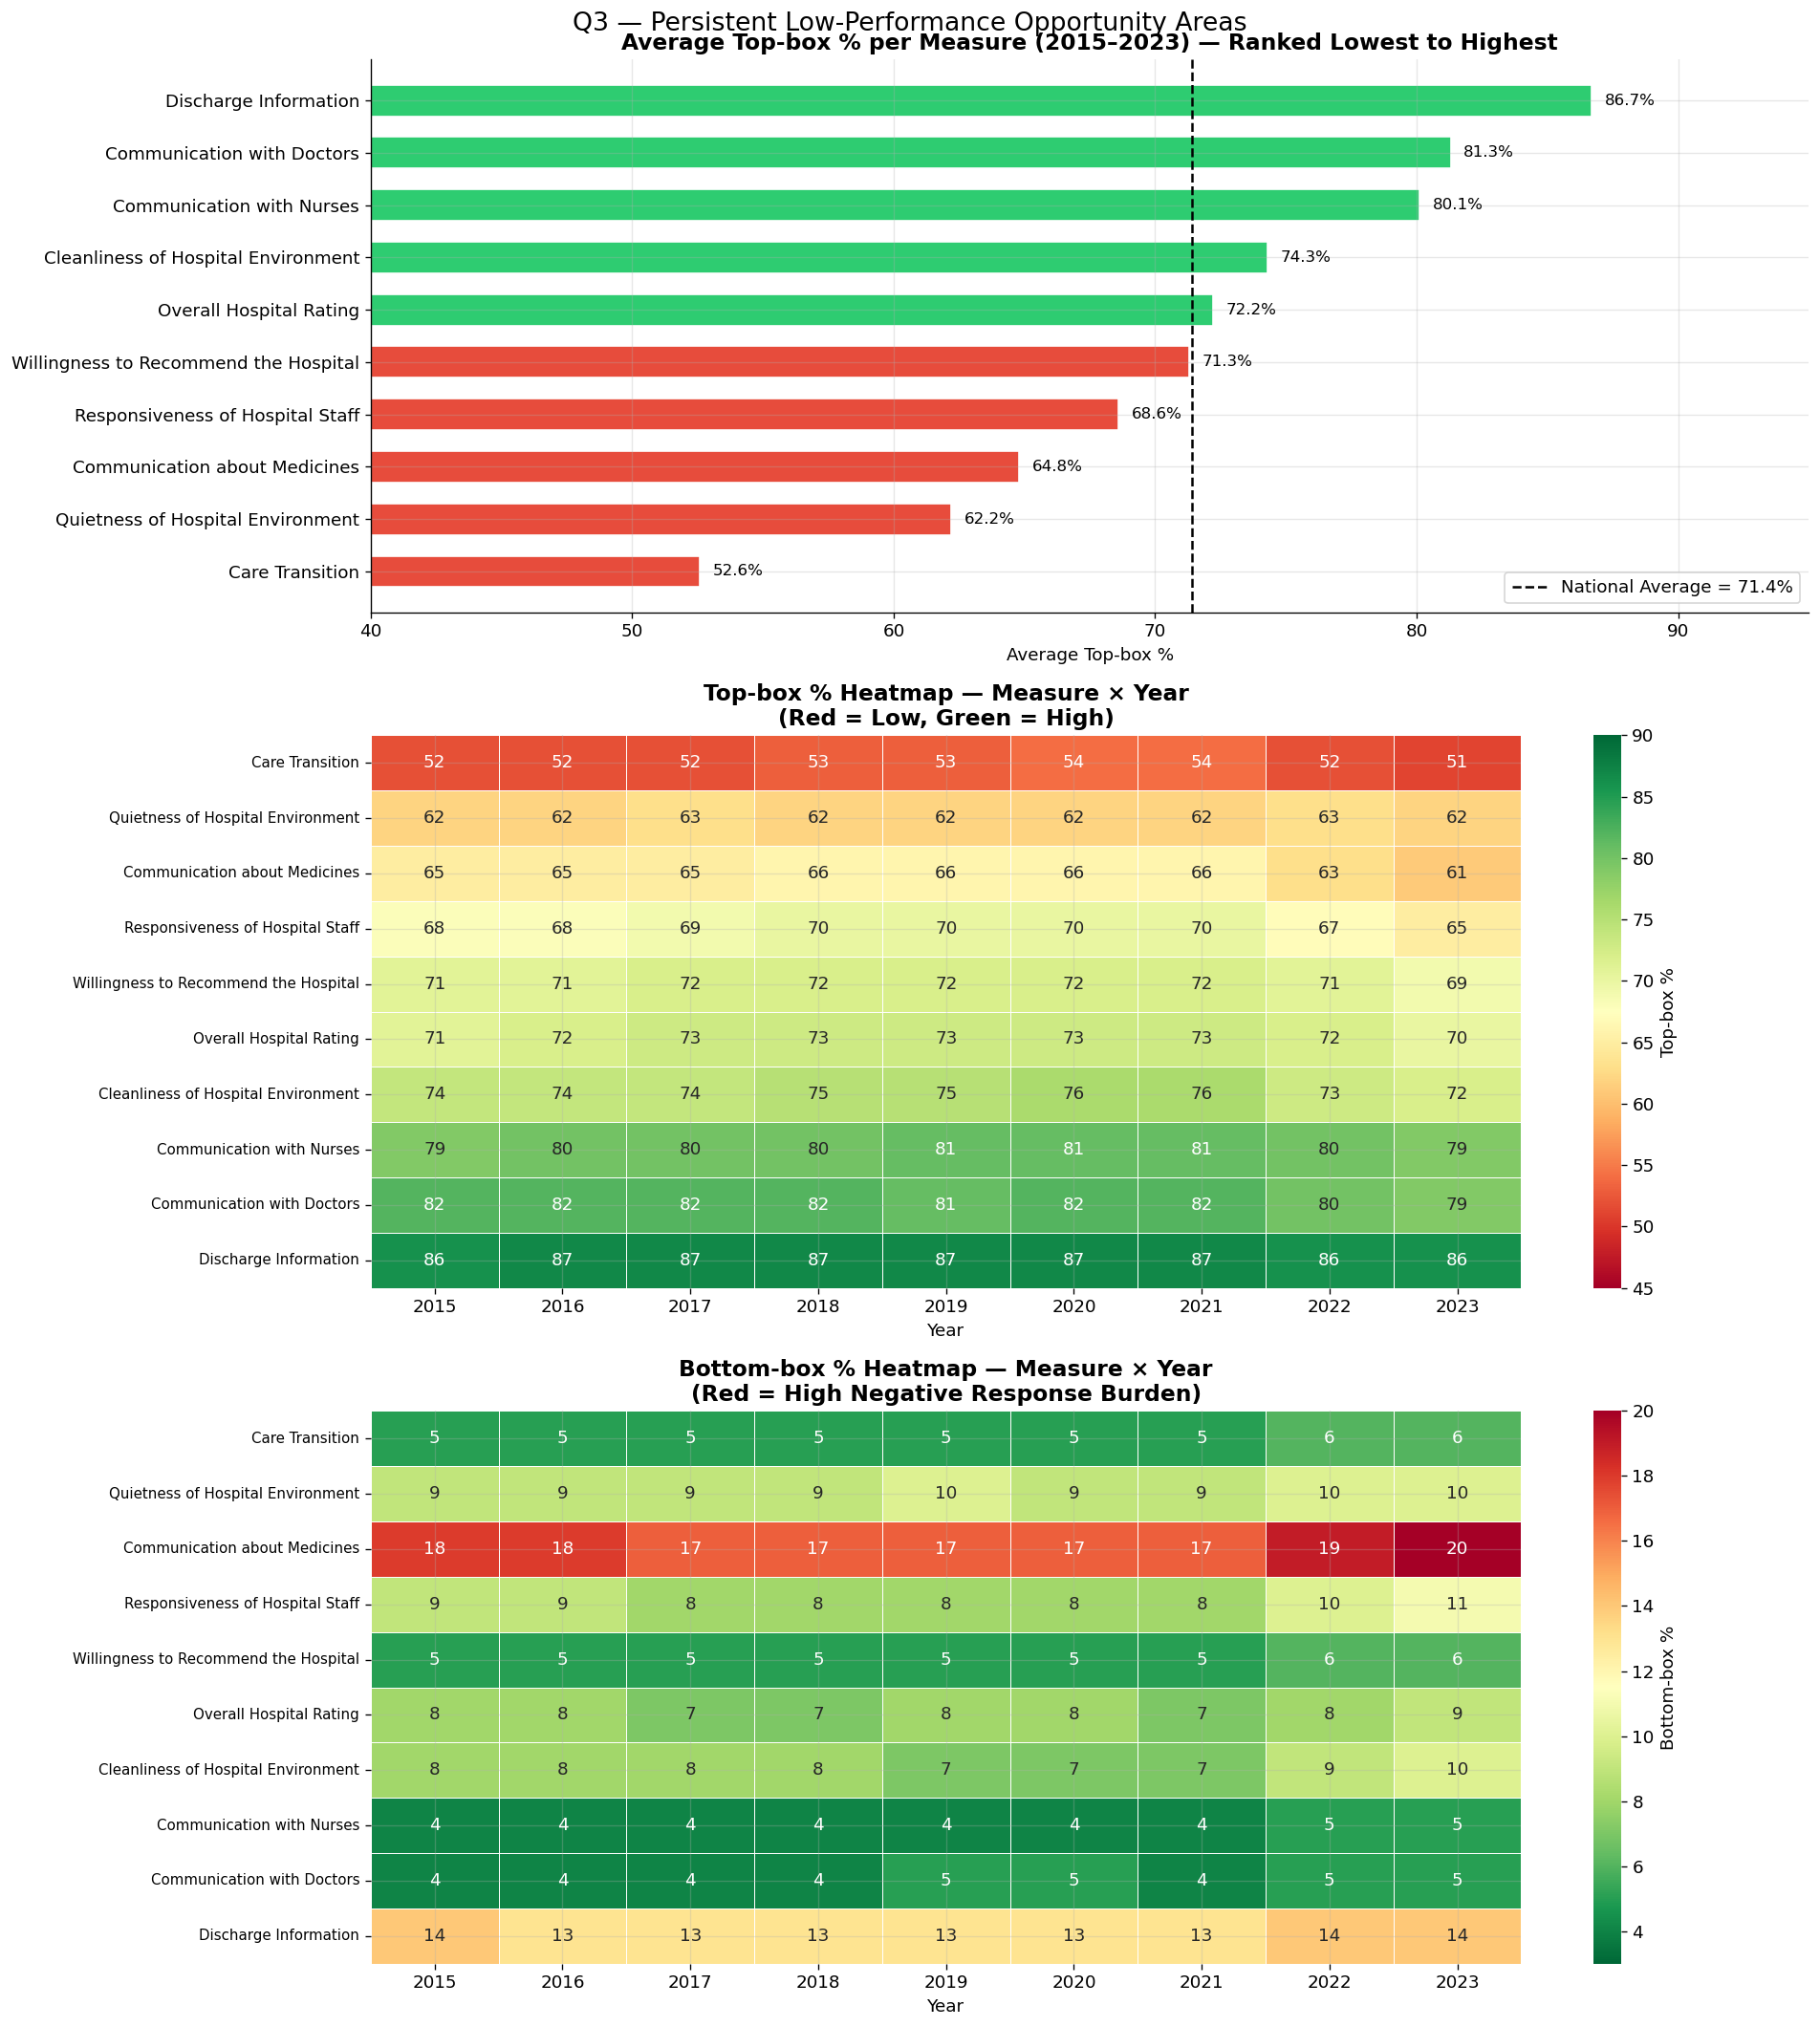

💾 Chart saved → /home/pharmacy/HCAHPS+Patient+Survey/Charts/04_Q3_Opportunity_Areas.png


In [9]:
# ============================================================
# Q3 — PERSISTENT LOW-PERFORMANCE AREAS
# ============================================================

# ── 1. Average Top-box % across all years per measure ────────
avg_by_measure = (national_df
                  .groupby('Measure')[['Top_pct', 'Bottom_pct']]
                  .mean()
                  .round(1)
                  .sort_values('Top_pct'))

print("📊 Average Top-box & Bottom-box % Across All Years")
print("─"*55)
display(avg_by_measure)
print()

# ── 2. Identify chronic underperformers ──────────────────────
threshold    = avg_by_measure['Top_pct'].mean()
low_perf     = avg_by_measure[avg_by_measure['Top_pct'] < threshold]

print(f"⚠️  National Average Top-box % : {threshold:.1f}%")
print(f"   Measures BELOW average ({len(low_perf)}):")
print("─"*55)
for m, row in low_perf.iterrows():
    gap = threshold - row['Top_pct']
    print(f"   ▼ {m:<42} {row['Top_pct']:.1f}%  "
          f"(gap: -{gap:.1f}pp)")
print()

# ── 3. Pivot for heatmap ─────────────────────────────────────
heatmap_top = (national_df
               .pivot_table(index='Measure',
                            columns='Year',
                            values='Top_pct'))

heatmap_bot = (national_df
               .pivot_table(index='Measure',
                            columns='Year',
                            values='Bottom_pct'))

# Sort by average Top-box ascending (worst at top)
measure_order = avg_by_measure.index.tolist()
heatmap_top   = heatmap_top.loc[measure_order]
heatmap_bot   = heatmap_bot.loc[measure_order]

# ── 4. Visualization — 3 panels ──────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 18))
fig.suptitle('Q3 — Persistent Low-Performance Opportunity Areas',
             fontsize=16)

# ── 4a. Average Top-box ranked bar ───────────────────────────
ax = axes[0]
colors = [BOT_COLOR if v < threshold else TOP_COLOR
          for v in avg_by_measure['Top_pct']]
bars = ax.barh(avg_by_measure.index,
               avg_by_measure['Top_pct'],
               color=colors, edgecolor='white', height=0.6)
ax.axvline(threshold, color='black', linestyle='--', linewidth=1.5,
           label=f'National Average = {threshold:.1f}%')
ax.set_title('Average Top-box % per Measure (2015–2023) — Ranked Lowest to Highest')
ax.set_xlabel('Average Top-box %')
ax.set_xlim(40, 95)
ax.legend()

for bar, val in zip(bars, avg_by_measure['Top_pct']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

# ── 4b. Top-box heatmap ───────────────────────────────────────
ax = axes[1]
sns.heatmap(heatmap_top,
            annot=True, fmt='.0f',
            cmap='RdYlGn',
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'label': 'Top-box %'},
            ax=ax,
            vmin=45, vmax=90)
ax.set_title('Top-box % Heatmap — Measure × Year\n'
             '(Red = Low, Green = High)')
ax.set_xlabel('Year')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=9)

# ── 4c. Bottom-box heatmap ────────────────────────────────────
ax = axes[2]
sns.heatmap(heatmap_bot,
            annot=True, fmt='.0f',
            cmap='RdYlGn_r',
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'label': 'Bottom-box %'},
            ax=ax,
            vmin=3, vmax=20)
ax.set_title('Bottom-box % Heatmap — Measure × Year\n'
             '(Red = High Negative Response Burden)')
ax.set_xlabel('Year')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
chart_path = os.path.join(CHARTS_DIR, '04_Q3_Opportunity_Areas.png')
plt.savefig(chart_path, bbox_inches='tight')
plt.show()
print(f"💾 Chart saved → {chart_path}")

## 7. Q4 — COVID-19 Impact: Did the Pandemic Cause a Visible Dip?

### Question
Did the COVID-19 pandemic (2020–2021) cause a measurable disruption
in HCAHPS patient experience scores, and did scores recover afterward?

### Approach
We analyze the pandemic's effect through three lenses:

- **Pre-COVID baseline** (2015–2019) average vs **COVID window**
  (2020–2021) vs **Post-COVID** (2022–2023)
- **Per-measure response** — which measures were hit hardest
  during and after the pandemic?
- **Recovery check** — did any measures bounce back to
  pre-COVID levels by 2023?

### Context
The COVID-19 pandemic placed unprecedented stress on hospital
systems worldwide. Staff shortages, PPE protocols, visitor
restrictions, and overwhelmed facilities could all be expected
to negatively affect patient-reported experiences.
Interestingly, some measures may have *improved* during COVID
if patients had lower expectations or felt more grateful for care.

📊 COVID-19 Impact — Period Averages per Measure
───────────────────────────────────────────────────────────────────────────


,Pre-COVID (2015–2019),COVID (2020–2021),Post-COVID (2022–2023),COVID Δ,Recovery Δ,Net Δ
Measure,,,,,,
Communication about Medicines,65.4,66.0,62.0,0.6,-4.0,-3.4
Responsiveness of Hospital Staff,69.0,70.0,66.0,1.0,-4.0,-3.0
Communication with Doctors,81.8,82.0,79.5,0.2,-2.5,-2.3
Cleanliness of Hospital Environment,74.4,76.0,72.5,1.6,-3.5,-1.9
Willingness to Recommend the Hospital,71.6,72.0,70.0,0.4,-2.0,-1.6
Overall Hospital Rating,72.4,73.0,71.0,0.6,-2.0,-1.4
Care Transition,52.4,54.0,51.5,1.6,-2.5,-0.9
Discharge Information,86.8,87.0,86.0,0.2,-1.0,-0.8
Communication with Nurses,80.0,81.0,79.5,1.0,-1.5,-0.5



📈 Overall Average Top-box %
   Pre-COVID  (2015–2019) : 71.6%
   COVID      (2020–2021) : 72.3%
   Post-COVID (2022–2023) : 70.0%
   COVID Δ                : +0.7%
   Post-COVID Δ           : -2.3%
   Net Δ                  : -1.6%



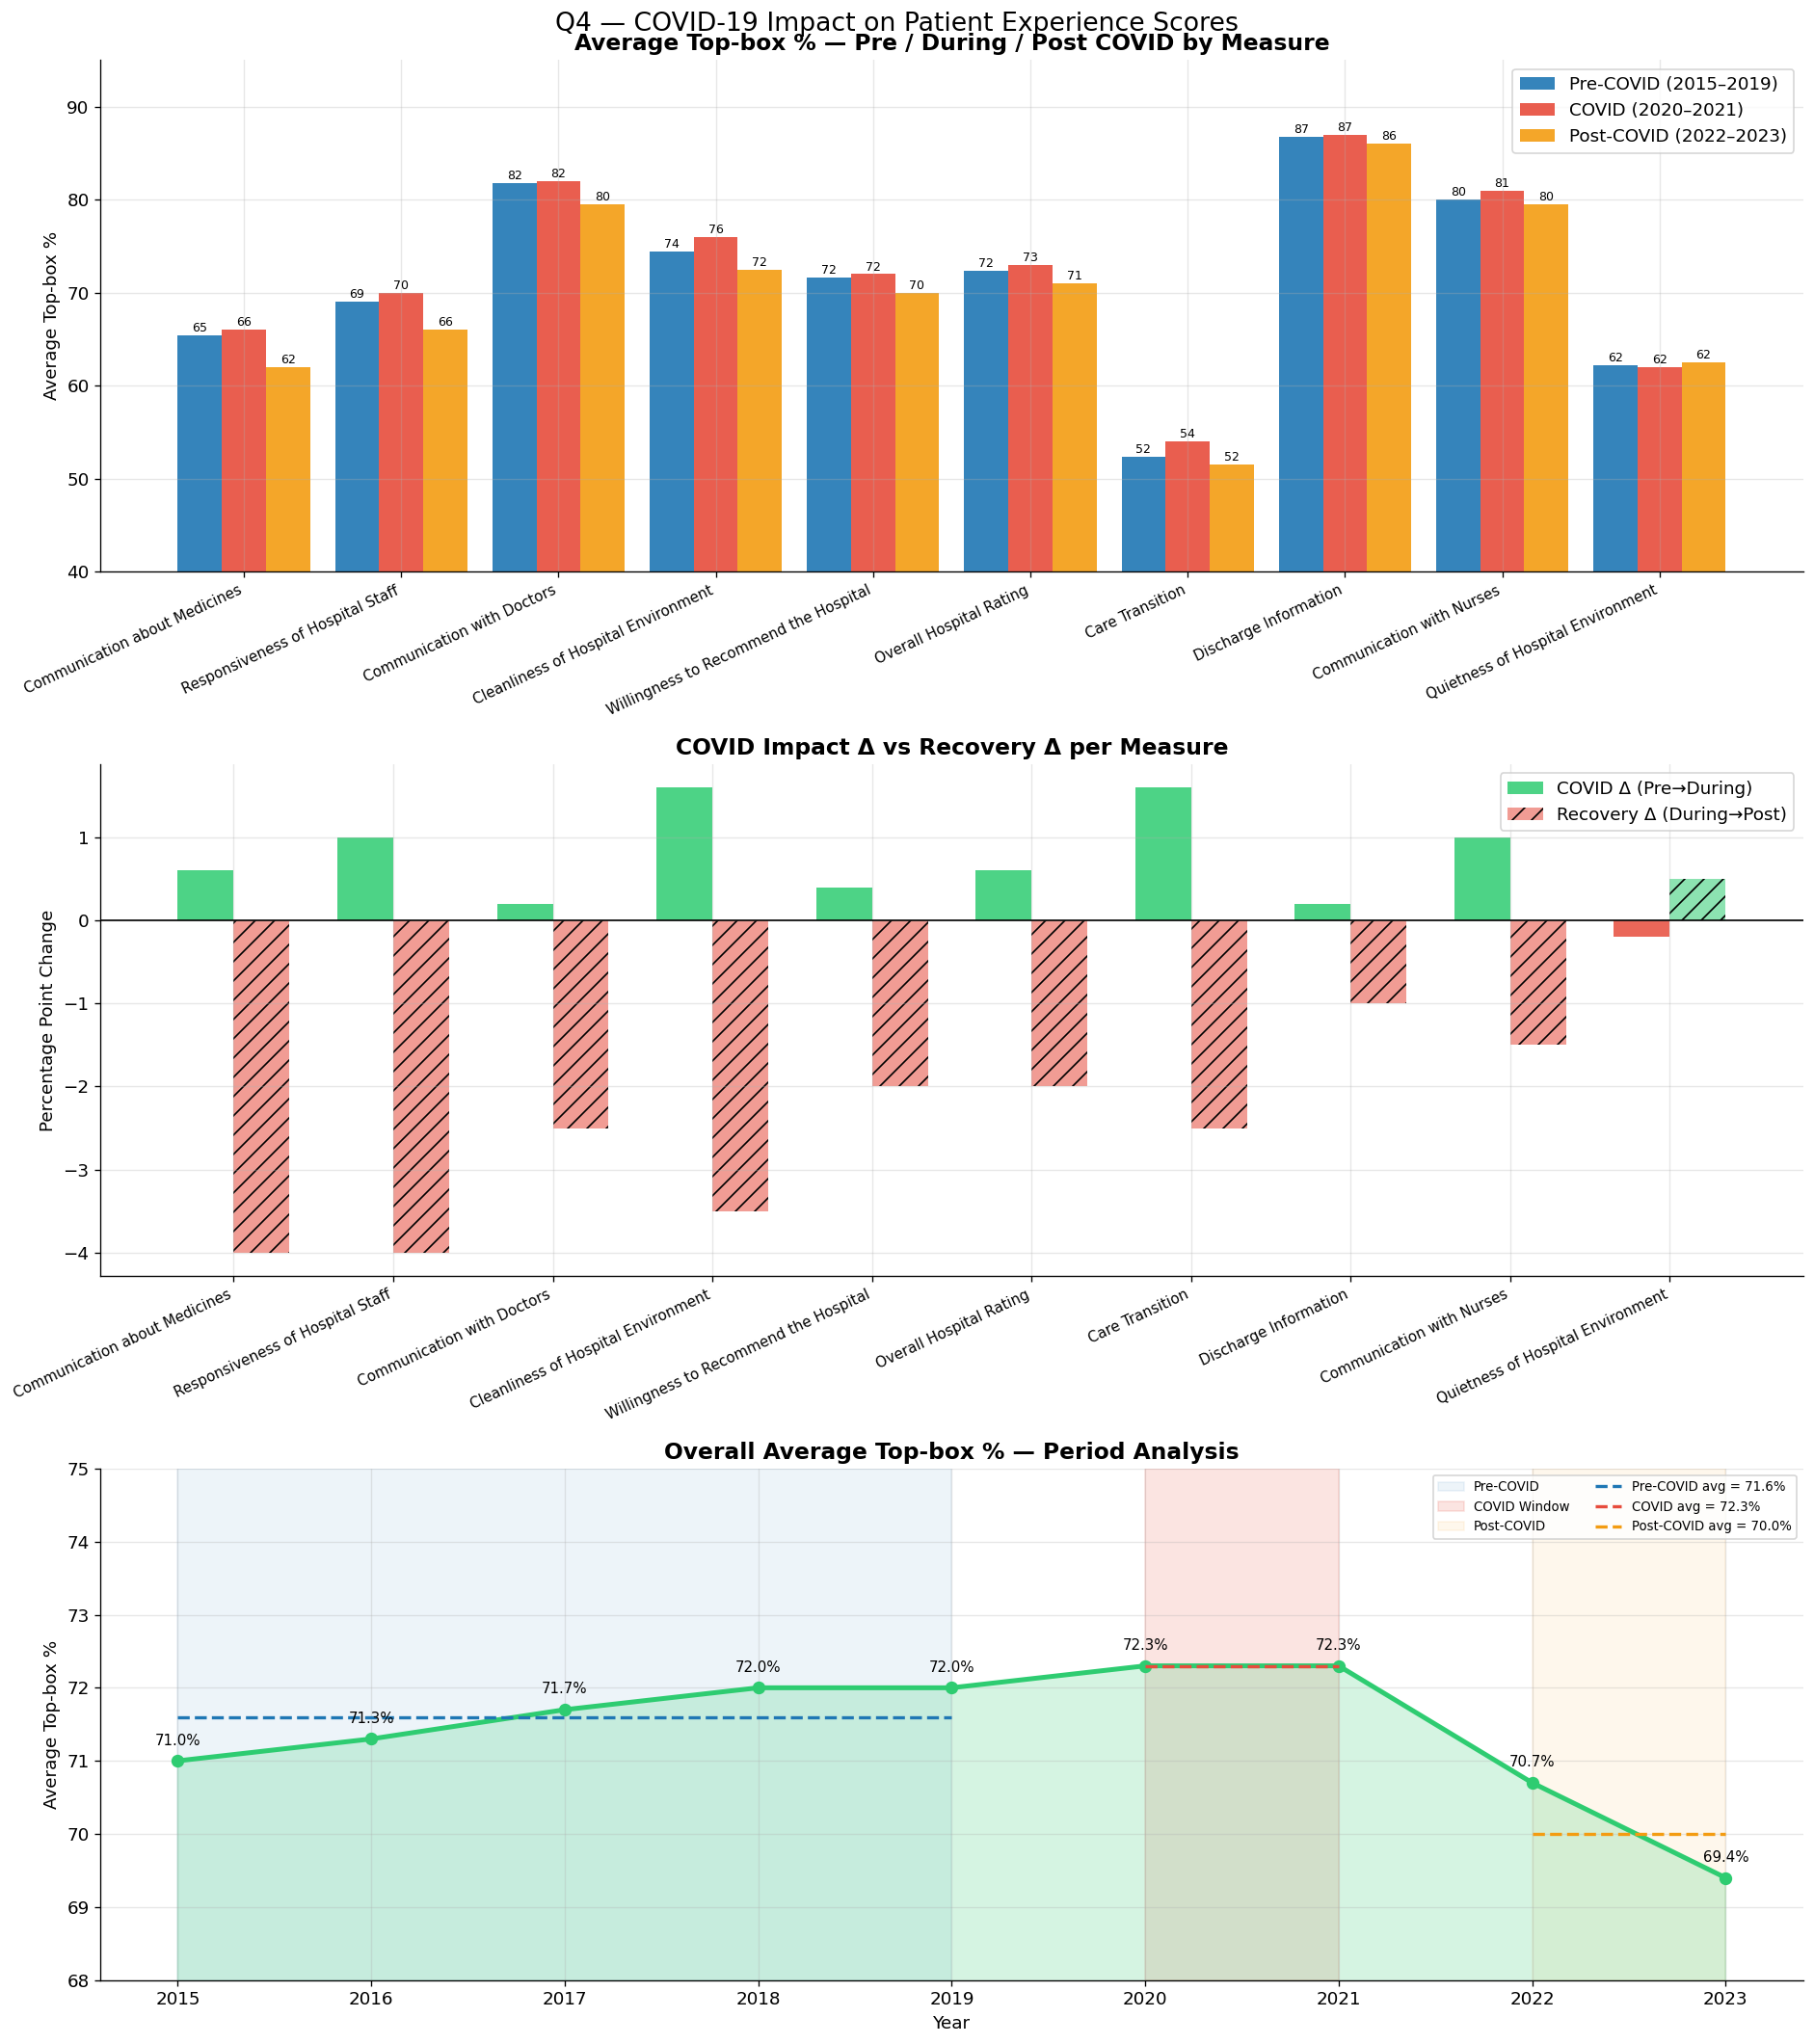

💾 Chart saved → /home/pharmacy/HCAHPS+Patient+Survey/Charts/05_Q4_COVID_Impact.png


In [10]:
# ============================================================
# Q4 — COVID-19 IMPACT ANALYSIS
# ============================================================

# ── 1. Define periods ─────────────────────────────────────────
pre_covid   = national_df[national_df['Year'] <= 2019]
covid       = national_df[national_df['Year'].isin([2020, 2021])]
post_covid  = national_df[national_df['Year'] >= 2022]

# ── 2. Period averages per measure ───────────────────────────
pre_avg  = (pre_covid .groupby('Measure')['Top_pct'].mean().round(1))
cov_avg  = (covid     .groupby('Measure')['Top_pct'].mean().round(1))
post_avg = (post_covid.groupby('Measure')['Top_pct'].mean().round(1))

covid_impact = pd.DataFrame({
    'Pre-COVID (2015–2019)' : pre_avg,
    'COVID (2020–2021)'     : cov_avg,
    'Post-COVID (2022–2023)': post_avg,
})
covid_impact['COVID Δ']    = (covid_impact['COVID (2020–2021)']
                              - covid_impact['Pre-COVID (2015–2019)']).round(1)
covid_impact['Recovery Δ'] = (covid_impact['Post-COVID (2022–2023)']
                              - covid_impact['COVID (2020–2021)']).round(1)
covid_impact['Net Δ']      = (covid_impact['Post-COVID (2022–2023)']
                              - covid_impact['Pre-COVID (2015–2019)']).round(1)

covid_impact = covid_impact.sort_values('Net Δ')

print("📊 COVID-19 Impact — Period Averages per Measure")
print("─"*75)
display(covid_impact)
print()

# ── 3. Overall period averages ────────────────────────────────
pre_overall  = pre_avg.mean().round(1)
cov_overall  = cov_avg.mean().round(1)
post_overall = post_avg.mean().round(1)

print(f"📈 Overall Average Top-box %")
print(f"   Pre-COVID  (2015–2019) : {pre_overall}%")
print(f"   COVID      (2020–2021) : {cov_overall}%")
print(f"   Post-COVID (2022–2023) : {post_overall}%")
print(f"   COVID Δ                : {cov_overall  - pre_overall:+.1f}%")
print(f"   Post-COVID Δ           : {post_overall - cov_overall:+.1f}%")
print(f"   Net Δ                  : {post_overall - pre_overall:+.1f}%")
print()

# ── 4. Visualization — 3 panels ──────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 18))
fig.suptitle('Q4 — COVID-19 Impact on Patient Experience Scores',
             fontsize=16)

# ── 4a. Three-period grouped bar per measure ──────────────────
ax = axes[0]
x     = np.arange(len(covid_impact))
width = 0.28

b1 = ax.bar(x - width, covid_impact['Pre-COVID (2015–2019)'],
            width, label='Pre-COVID (2015–2019)',
            color=PALETTE[0], alpha=0.9)
b2 = ax.bar(x,          covid_impact['COVID (2020–2021)'],
            width, label='COVID (2020–2021)',
            color=BOT_COLOR, alpha=0.9)
b3 = ax.bar(x + width,  covid_impact['Post-COVID (2022–2023)'],
            width, label='Post-COVID (2022–2023)',
            color=MID_COLOR, alpha=0.9)

ax.set_title('Average Top-box % — Pre / During / Post COVID by Measure')
ax.set_ylabel('Average Top-box %')
ax.set_xticks(x)
ax.set_xticklabels(covid_impact.index, rotation=25, ha='right', fontsize=9)
ax.set_ylim(40, 95)
ax.legend()

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.4,
                f'{bar.get_height():.0f}',
                ha='center', fontsize=7.5)

# ── 4b. COVID Δ and Recovery Δ diverging bars ─────────────────
ax = axes[1]
x2    = np.arange(len(covid_impact))
width2= 0.35

covid_colors    = [TOP_COLOR if v >= 0 else BOT_COLOR
                   for v in covid_impact['COVID Δ']]
recovery_colors = [TOP_COLOR if v >= 0 else BOT_COLOR
                   for v in covid_impact['Recovery Δ']]

ax.bar(x2 - width2/2, covid_impact['COVID Δ'],
       width2, color=covid_colors,
       alpha=0.85, label='COVID Δ (Pre→During)')
ax.bar(x2 + width2/2, covid_impact['Recovery Δ'],
       width2, color=recovery_colors,
       alpha=0.55, label='Recovery Δ (During→Post)',
       hatch='//')

ax.axhline(0, color='black', linewidth=1)
ax.set_title('COVID Impact Δ vs Recovery Δ per Measure')
ax.set_ylabel('Percentage Point Change')
ax.set_xticks(x2)
ax.set_xticklabels(covid_impact.index, rotation=25, ha='right', fontsize=9)
ax.legend()

# ── 4c. Overall trend with period shading ────────────────────
ax = axes[2]
avg_trend = national_df.groupby('Year')['Top_pct'].mean()

# Period backgrounds
ax.axvspan(2015, 2019, alpha=0.08, color=PALETTE[0], label='Pre-COVID')
ax.axvspan(2020, 2021, alpha=0.15, color=BOT_COLOR,  label='COVID Window')
ax.axvspan(2022, 2023, alpha=0.08, color=MID_COLOR,  label='Post-COVID')

ax.fill_between(avg_trend.index, avg_trend.values,
                alpha=0.2, color=TOP_COLOR)
ax.plot(avg_trend.index, avg_trend.values,
        marker='o', color=TOP_COLOR, linewidth=3)

# Period average lines
ax.hlines(pre_overall,  2015, 2019, colors=PALETTE[0],
          linestyles='--', linewidth=2,
          label=f'Pre-COVID avg = {pre_overall}%')
ax.hlines(cov_overall,  2020, 2021, colors=BOT_COLOR,
          linestyles='--', linewidth=2,
          label=f'COVID avg = {cov_overall}%')
ax.hlines(post_overall, 2022, 2023, colors=MID_COLOR,
          linestyles='--', linewidth=2,
          label=f'Post-COVID avg = {post_overall}%')

for x, y in zip(avg_trend.index, avg_trend.values):
    ax.annotate(f'{y:.1f}%', (x, y),
                textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)

ax.set_title('Overall Average Top-box % — Period Analysis')
ax.set_xlabel('Year')
ax.set_ylabel('Average Top-box %')
ax.set_xticks(avg_trend.index)
ax.set_ylim(68, 75)
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
chart_path = os.path.join(CHARTS_DIR, '05_Q4_COVID_Impact.png')
plt.savefig(chart_path, bbox_inches='tight')
plt.show()
print(f"💾 Chart saved → {chart_path}")

## 8. Q5 — Geographic Analysis: Which States and Regions Consistently Outperform?

### Question
Is patient experience uniform across the United States, or are there
significant geographic patterns — states and Census regions that
consistently score higher or lower than the national average?

### Approach
We analyze geographic variation through three lenses:

- **Regional averages** — compare the 9 US Census regions by
  average Top-box % across all measures and all years
- **State rankings** — identify the top 10 and bottom 10
  performing states averaged over 9 years
- **Regional trends over time** — did regional gaps widen
  or narrow between 2015 and 2023?

### Why this matters
Geographic patterns reveal whether poor performance is a
national systemic issue or concentrated in specific areas.
States that consistently outperform can serve as benchmarks
and best-practice models for lower-performing peers.

📊 Average Top-box % by Census Region (All Years & Measures)
───────────────────────────────────────────────────────
  West North Central        74.9%  (+3.6pp vs avg)
  West South Central        73.7%  (+2.4pp vs avg)
  East North Central        72.4%  (+1.1pp vs avg)
  East South Central        72.4%  (+1.1pp vs avg)
  Mountain                  71.2%  (-0.1pp vs avg)
  New England               71.2%  (-0.1pp vs avg)
  Pacific                   70.0%  (-1.3pp vs avg)
  South Atlantic            68.8%  (-2.5pp vs avg)
  Mid-Atlantic              67.3%  (-4.0pp vs avg)

  National State Average : 71.3%

🏆 Top 10 States
────────────────────────────────────────
  South Dakota                   76.8%
  Nebraska                       76.7%
  Louisiana                      76.1%
  Kansas                         75.4%
  Minnesota                      75.4%
  Iowa                           75.1%
  Wisconsin                      75.1%
  Idaho                          74.5%
  North Dakota       

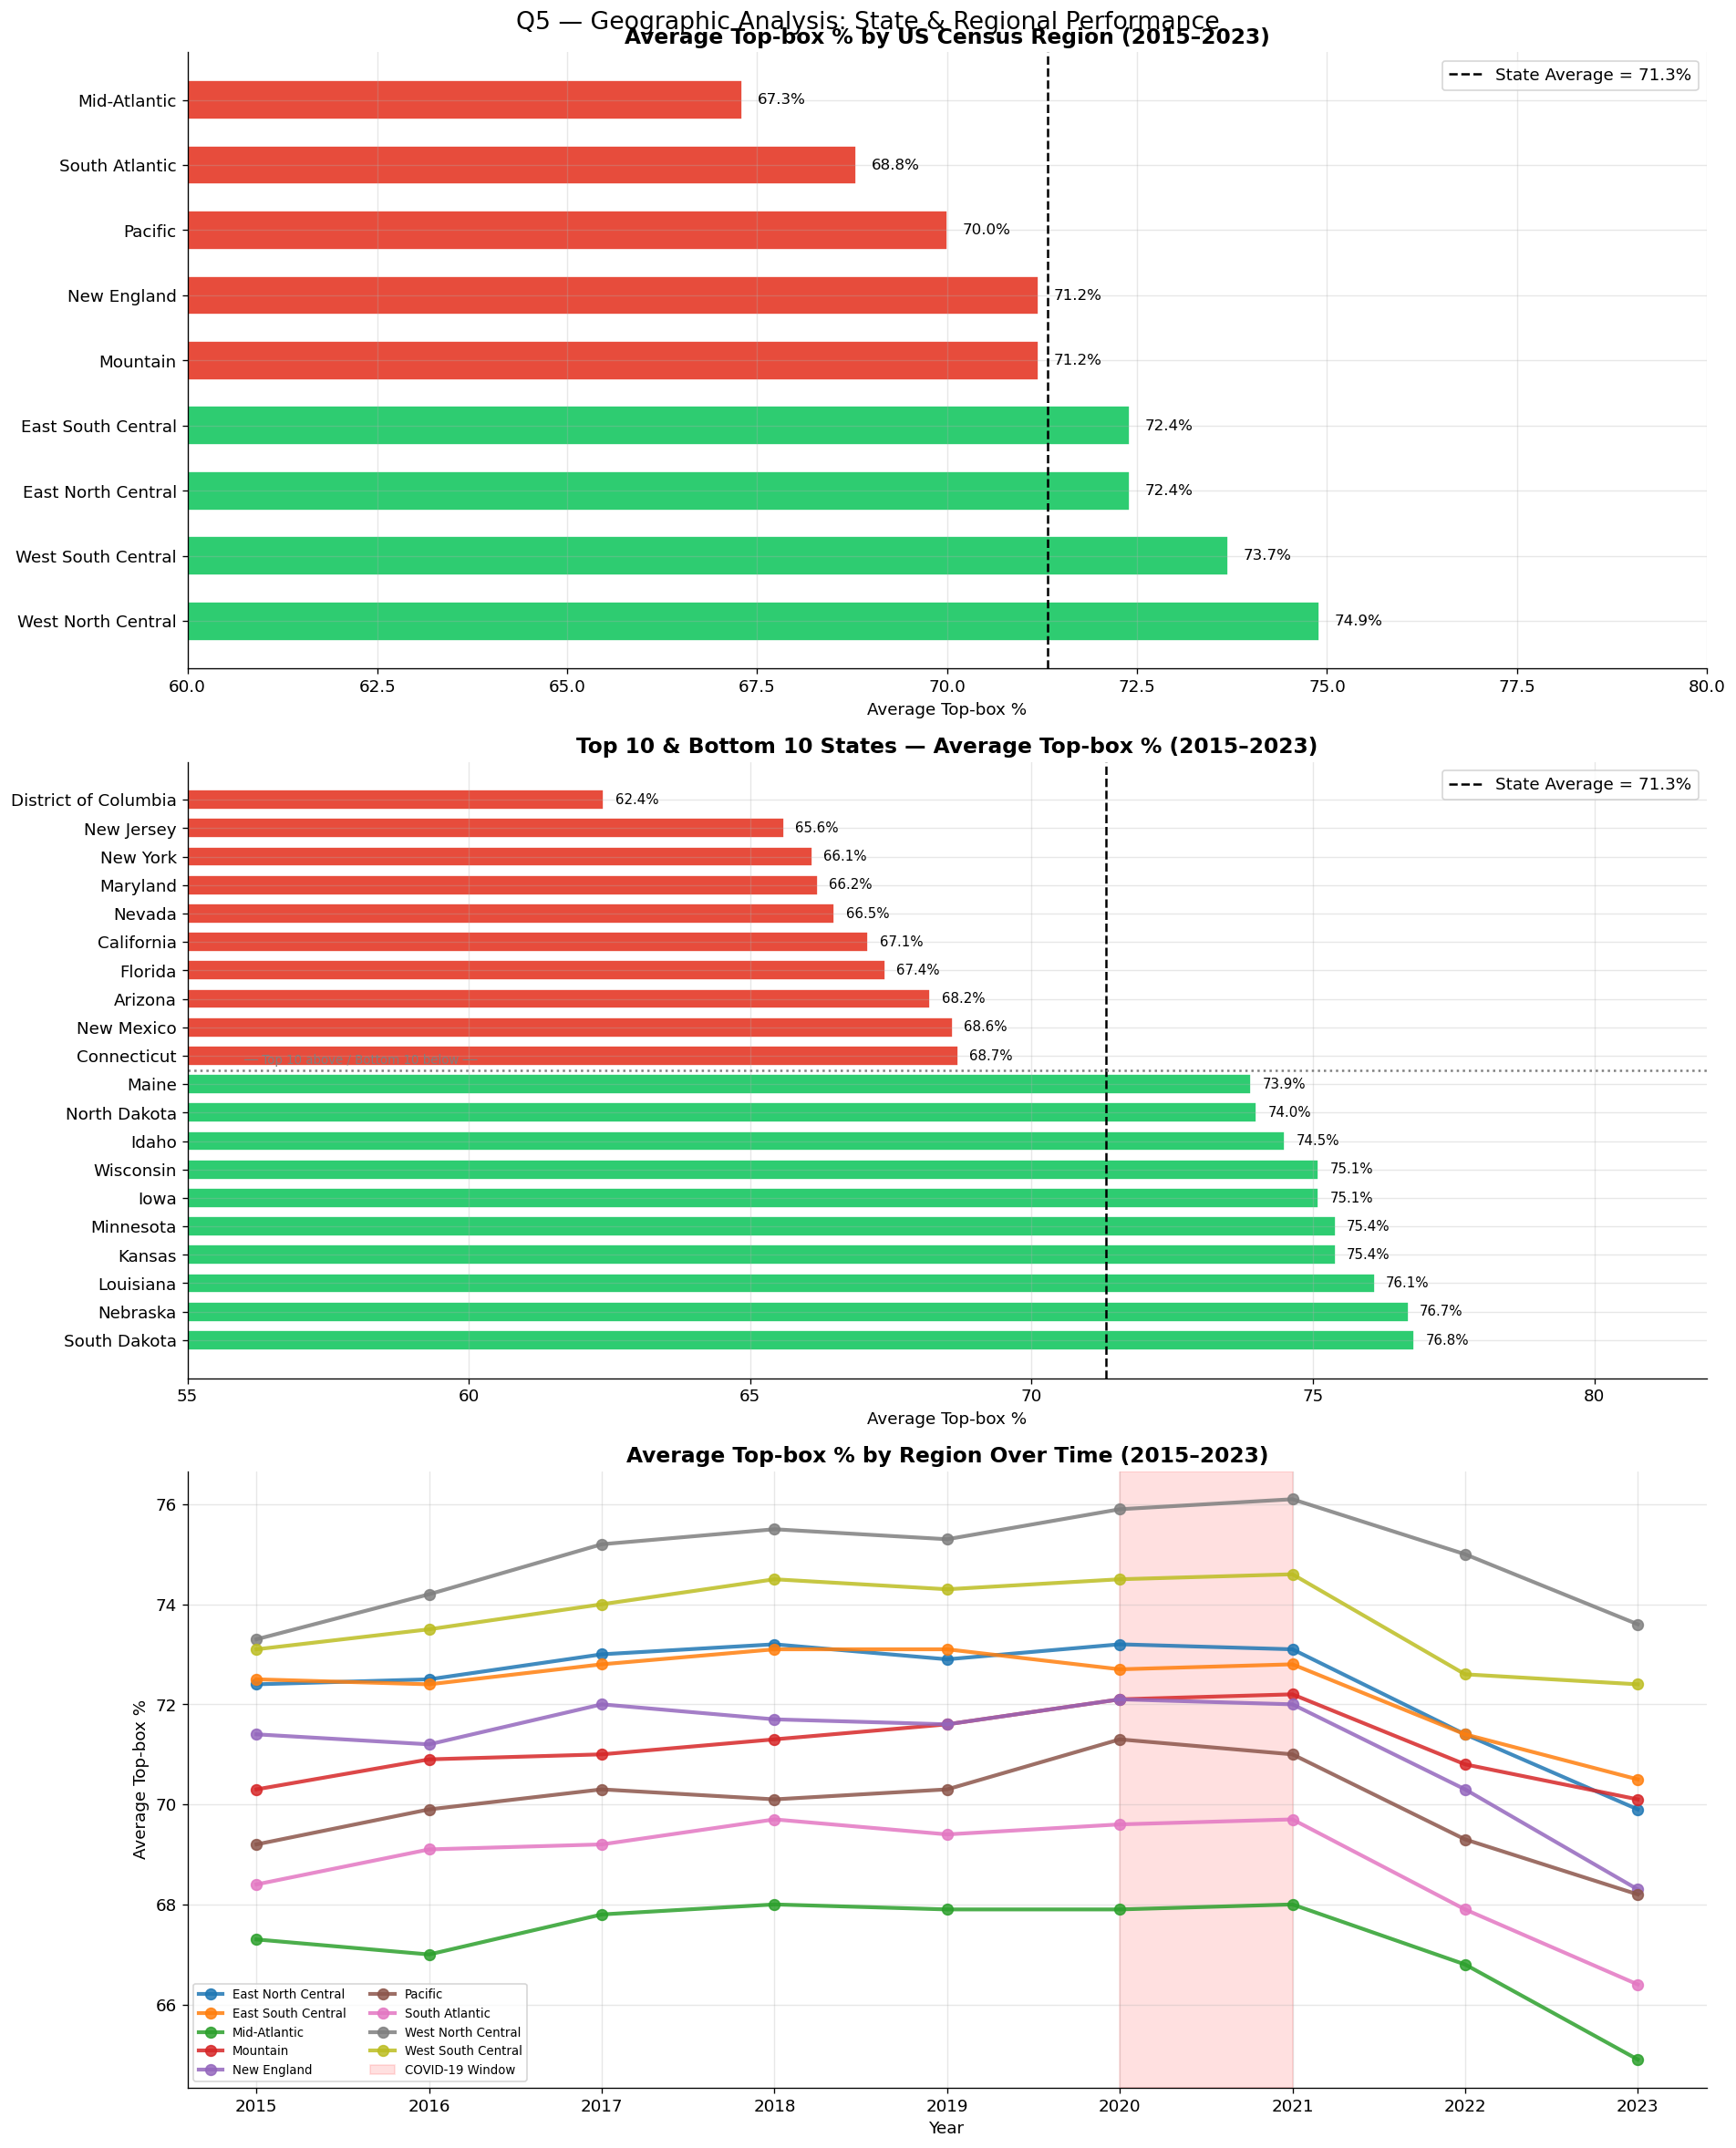

💾 Chart saved → /home/pharmacy/HCAHPS+Patient+Survey/Charts/06_Q5_Geographic_Analysis.png


In [11]:
# ============================================================
# Q5 — GEOGRAPHIC ANALYSIS
# ============================================================

# ── 1. Regional averages across all years & measures ─────────
region_avg = (state_df
              .groupby('Region')['Top_pct']
              .mean()
              .round(1)
              .sort_values(ascending=False))

print("📊 Average Top-box % by Census Region (All Years & Measures)")
print("─"*55)
for region, val in region_avg.items():
    gap = val - region_avg.mean()
    bar = '█' * int(abs(gap))
    sign= '+' if gap >= 0 else '-'
    print(f"  {region:<25} {val:.1f}%  ({sign}{abs(gap):.1f}pp vs avg)")
print(f"\n  National State Average : {region_avg.mean():.1f}%")
print()

# ── 2. State averages across all years & measures ────────────
state_avg = (state_df
             .groupby(['State', 'State_Name'])['Top_pct']
             .mean()
             .round(1)
             .sort_values(ascending=False))

top10    = state_avg.head(10)
bottom10 = state_avg.tail(10)

print("🏆 Top 10 States")
print("─"*40)
for (state, name), val in top10.items():
    print(f"  {name:<30} {val:.1f}%")
print()
print("⚠️  Bottom 10 States")
print("─"*40)
for (state, name), val in bottom10.items():
    print(f"  {name:<30} {val:.1f}%")
print()

# ── 3. Regional trend over time ──────────────────────────────
region_trend = (state_df
                .groupby(['Region', 'Year'])['Top_pct']
                .mean()
                .round(1)
                .reset_index())

# ── 4. Visualization — 3 panels ──────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 20))
fig.suptitle('Q5 — Geographic Analysis: State & Regional Performance',
             fontsize=16)

# ── 4a. Regional average bar chart ───────────────────────────
ax = axes[0]
nat_avg = region_avg.mean()
colors  = [TOP_COLOR if v >= nat_avg else BOT_COLOR
           for v in region_avg.values]

bars = ax.barh(region_avg.index,
               region_avg.values,
               color=colors, edgecolor='white', height=0.6)
ax.axvline(nat_avg, color='black', linestyle='--', linewidth=1.5,
           label=f'State Average = {nat_avg:.1f}%')
ax.set_title('Average Top-box % by US Census Region (2015–2023)')
ax.set_xlabel('Average Top-box %')
ax.set_xlim(60, 80)
ax.legend()

for bar, val in zip(bars, region_avg.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

# ── 4b. Top 10 & Bottom 10 states ────────────────────────────
ax = axes[1]
top10_vals    = top10.values
top10_labels  = [name for (_, name) in top10.index]
bot10_vals    = bottom10.values
bot10_labels  = [name for (_, name) in bottom10.index]

all_labels = top10_labels + bot10_labels
all_vals   = list(top10_vals) + list(bot10_vals)
all_colors = [TOP_COLOR] * 10 + [BOT_COLOR] * 10

bars2 = ax.barh(all_labels, all_vals,
                color=all_colors, edgecolor='white', height=0.7)
ax.axvline(nat_avg, color='black', linestyle='--', linewidth=1.5,
           label=f'State Average = {nat_avg:.1f}%')
ax.set_title('Top 10 & Bottom 10 States — Average Top-box % (2015–2023)')
ax.set_xlabel('Average Top-box %')
ax.set_xlim(55, 82)
ax.legend()

for bar, val in zip(bars2, all_vals):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

# Separator line between top and bottom
ax.axhline(9.5, color='gray', linestyle=':', linewidth=1.5)
ax.text(56, 9.7, '── Top 10 above / Bottom 10 below ──',
        fontsize=8, color='gray')

# ── 4c. Regional trend over time ─────────────────────────────
ax = axes[2]
regions = region_trend['Region'].unique()

for i, region in enumerate(sorted(regions)):
    data = region_trend[region_trend['Region'] == region]
    ax.plot(data['Year'], data['Top_pct'],
            marker='o', color=PALETTE[i],
            label=region, alpha=0.85)

ax.axvspan(2020, 2021, alpha=0.12, color='red', label='COVID-19 Window')
ax.set_title('Average Top-box % by Region Over Time (2015–2023)')
ax.set_xlabel('Year')
ax.set_ylabel('Average Top-box %')
ax.set_xticks(region_trend['Year'].unique())
ax.legend(fontsize=8, ncol=2, loc='lower left')

plt.tight_layout()
chart_path = os.path.join(CHARTS_DIR, '06_Q5_Geographic_Analysis.png')
plt.savefig(chart_path, bbox_inches='tight')
plt.show()
print(f"💾 Chart saved → {chart_path}")

## 9. Q6 — Response Rate Trends: Is the Survey Data Becoming Less Reliable?

### Question
Are patient response rates and survey completion volumes changing
over time in ways that could affect the reliability of HCAHPS scores?

### Approach
We examine facility-level response data across all 9 years:

- **National average response rate trend** — is participation
  rising or falling over time?
- **Survey volume distribution** — how are facilities distributed
  across the three completion categories (Fewer than 100,
  Between 100 and 299, 300 or more)?
- **Response rate by state** — which states have the highest
  and lowest patient participation rates?
- **Correlation check** — do facilities with higher response
  rates tend to score higher on Top-box measures?

### Why this matters
A declining response rate introduces **non-response bias** —
if only certain types of patients respond, scores may no longer
represent the true patient population. This directly affects
the validity of all conclusions drawn from HCAHPS data.

📊 National Response Rate (%) by Year
─────────────────────────────────────────────


,Mean RR,Median RR,Std Dev
Year,,,
2015,30.8,30.0,8.7
2016,29.5,29.0,8.7
2017,28.4,28.0,8.6
2018,27.0,26.0,8.8
2019,26.0,25.0,8.9
2020,25.8,25.0,9.1
2021,25.4,24.0,9.1
2022,23.8,23.0,8.8
2023,22.7,21.0,8.7



📋 Facility Count by Survey Volume Category
───────────────────────────────────────────────────────


Completed Surveys,Fewer than 100,Between 100 and 299,300 or more,Not Available
Year,,,,
2015,612,777,2771,496
2016,0,0,0,437
2017,0,0,0,709
2018,0,0,0,671
2019,0,0,0,674
2020,0,0,0,664
2021,0,0,0,695
2022,0,0,0,710
2023,0,0,0,716



🏆 Top 10 States by Avg Response Rate
────────────────────────────────────────
State
NE    36.3
WI    35.1
MN    34.5
IA    33.7
ND    33.6
SD    33.2
KS    32.8
PA    31.6
ID    31.0
MT    30.9

⚠️  Bottom 10 States by Avg Response Rate
────────────────────────────────────────
State
NV    22.6
MD    22.1
AK    21.8
NJ    21.4
GA    21.1
NM    20.8
DC    20.6
AS     NaN
GU     NaN
MP     NaN

📈 Correlation — Response Rate vs Top-box %: 0.593



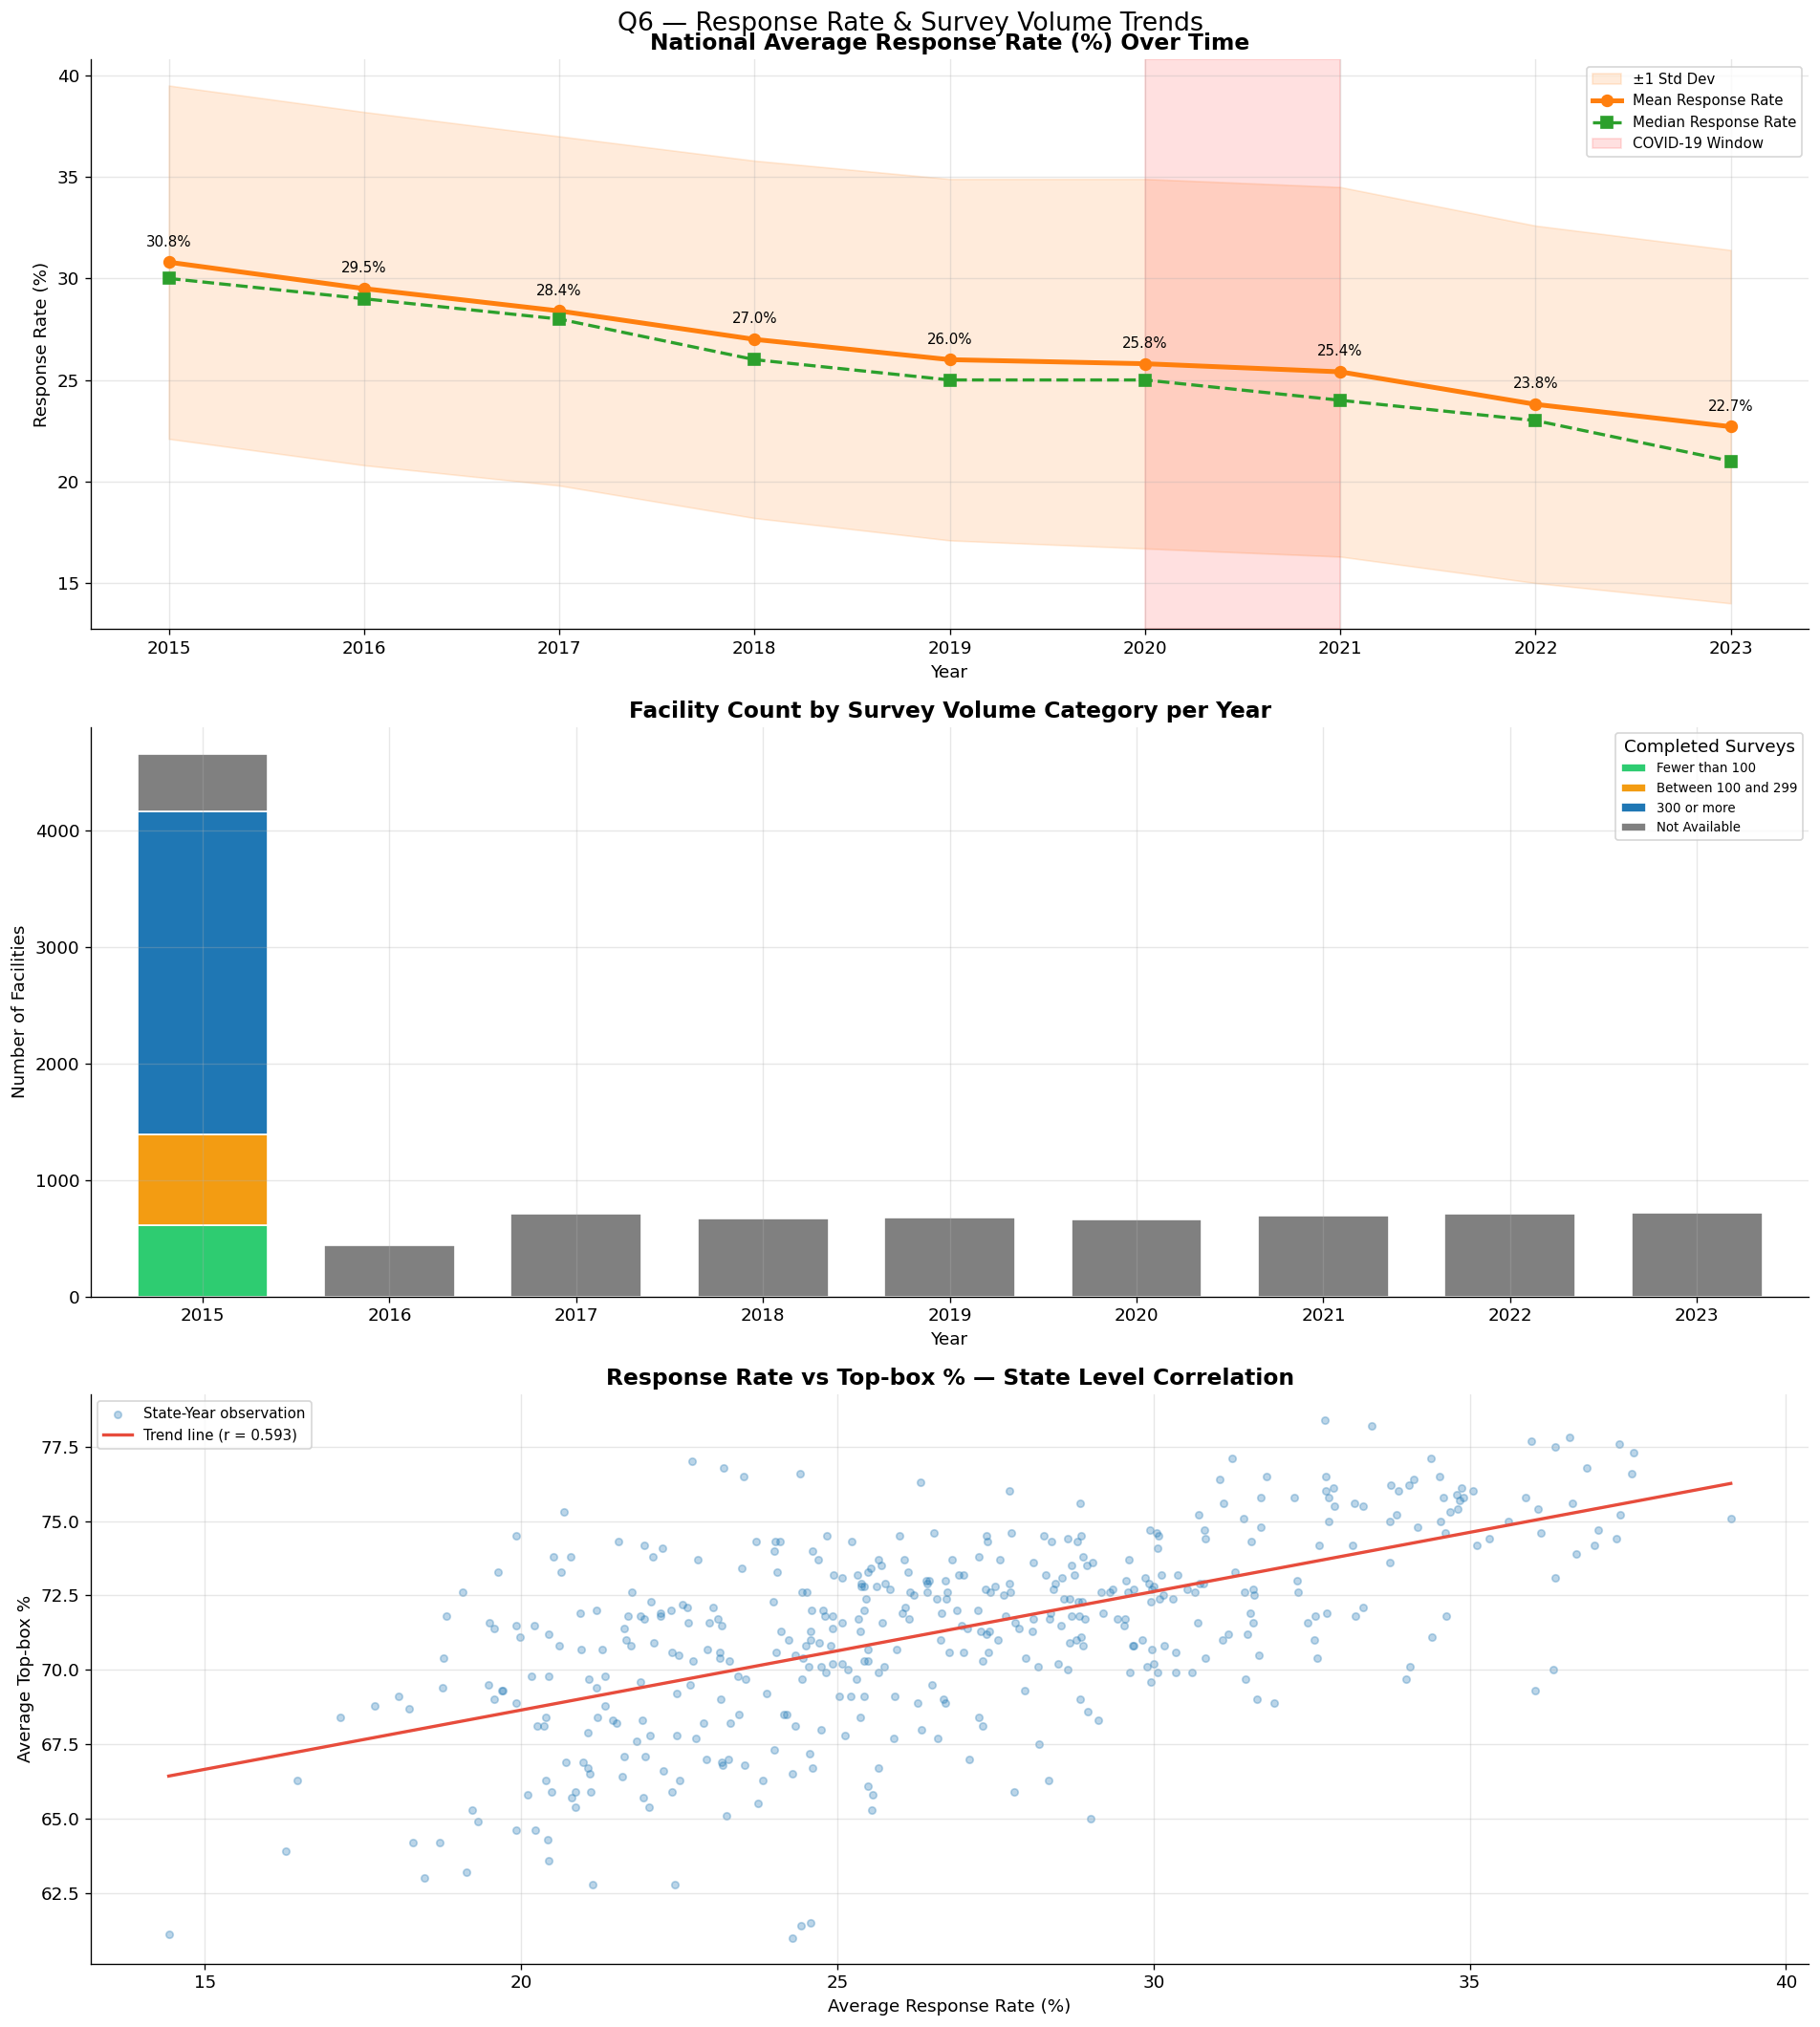

💾 Chart saved → /home/pharmacy/HCAHPS+Patient+Survey/Charts/07_Q6_Response_Rate_Trends.png


In [12]:
# ============================================================
# Q6 — RESPONSE RATE TRENDS
# ============================================================

# ── 1. National average response rate by year ────────────────
rr_national = (responses
               .groupby('Year')['Response Rate (%)']
               .agg(['mean', 'median', 'std'])
               .round(1))
rr_national.columns = ['Mean RR', 'Median RR', 'Std Dev']

print("📊 National Response Rate (%) by Year")
print("─"*45)
display(rr_national)
print()

# ── 2. Survey volume distribution by year ────────────────────
vol_dist = (responses
            .groupby(['Year', 'Completed Surveys'])
            .size()
            .unstack(fill_value=0))

# Reorder columns
col_order = ['Fewer than 100', 'Between 100 and 299',
             '300 or more', 'Not Available']
col_order = [c for c in col_order if c in vol_dist.columns]
vol_dist  = vol_dist[col_order]

print("📋 Facility Count by Survey Volume Category")
print("─"*55)
display(vol_dist)
print()

# ── 3. Response rate by state (all years avg) ─────────────────
rr_by_state = (responses
               .groupby('State')['Response Rate (%)']
               .mean()
               .round(1)
               .sort_values(ascending=False))

print("🏆 Top 10 States by Avg Response Rate")
print("─"*40)
print(rr_by_state.head(10).to_string())
print()
print("⚠️  Bottom 10 States by Avg Response Rate")
print("─"*40)
print(rr_by_state.tail(10).to_string())
print()

# ── 4. Correlation: response rate vs top-box % ───────────────
# Merge responses with state_results on Year + State
rr_corr = (responses
           .groupby(['Year', 'State'])['Response Rate (%)']
           .mean()
           .reset_index())

state_top = (state_df
             .groupby(['Year', 'State'])['Top_pct']
             .mean()
             .reset_index())

corr_df = rr_corr.merge(state_top, on=['Year', 'State'])
corr_val = corr_df[['Response Rate (%)', 'Top_pct']].corr().iloc[0, 1]

print(f"📈 Correlation — Response Rate vs Top-box %: {corr_val:.3f}")
print()

# ── 5. Visualization — 3 panels ──────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 18))
fig.suptitle('Q6 — Response Rate & Survey Volume Trends',
             fontsize=16)

# ── 5a. Response rate trend ───────────────────────────────────
ax = axes[0]
ax.fill_between(rr_national.index,
                rr_national['Mean RR'] - rr_national['Std Dev'],
                rr_national['Mean RR'] + rr_national['Std Dev'],
                alpha=0.15, color=PALETTE[1], label='±1 Std Dev')
ax.plot(rr_national.index, rr_national['Mean RR'],
        marker='o', color=PALETTE[1],
        linewidth=3, label='Mean Response Rate')
ax.plot(rr_national.index, rr_national['Median RR'],
        marker='s', color=PALETTE[2], linestyle='--',
        linewidth=2, label='Median Response Rate')

ax.axvspan(2020, 2021, alpha=0.12, color='red',
           label='COVID-19 Window')

for x, y in zip(rr_national.index, rr_national['Mean RR']):
    ax.annotate(f'{y:.1f}%', (x, y),
                textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)

ax.set_title('National Average Response Rate (%) Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Response Rate (%)')
ax.set_xticks(rr_national.index)
ax.legend(fontsize=9)

# ── 5b. Survey volume stacked bar ────────────────────────────
ax = axes[1]
vol_colors = [TOP_COLOR, MID_COLOR, PALETTE[0], 'gray']
vol_dist.plot(kind='bar', stacked=True,
              color=vol_colors[:len(col_order)],
              ax=ax, edgecolor='white', width=0.7)

ax.set_title('Facility Count by Survey Volume Category per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Facilities')
ax.set_xticklabels(vol_dist.index, rotation=0)
ax.legend(title='Completed Surveys', fontsize=8,
          loc='upper right')

# ── 5c. Scatter: response rate vs top-box % ──────────────────
ax = axes[2]
scatter = ax.scatter(corr_df['Response Rate (%)'],
                     corr_df['Top_pct'],
                     alpha=0.3, color=PALETTE[0],
                     s=20, label='State-Year observation')

# Trend line
z   = np.polyfit(corr_df['Response Rate (%)'].dropna(),
                 corr_df.loc[corr_df['Response Rate (%)'].notna(),
                             'Top_pct'], 1)
p   = np.poly1d(z)
x_line = np.linspace(corr_df['Response Rate (%)'].min(),
                     corr_df['Response Rate (%)'].max(), 100)
ax.plot(x_line, p(x_line), color=BOT_COLOR,
        linewidth=2, label=f'Trend line (r = {corr_val:.3f})')

ax.set_title('Response Rate vs Top-box % — State Level Correlation')
ax.set_xlabel('Average Response Rate (%)')
ax.set_ylabel('Average Top-box %')
ax.legend(fontsize=9)

plt.tight_layout()
chart_path = os.path.join(CHARTS_DIR, '07_Q6_Response_Rate_Trends.png')
plt.savefig(chart_path, bbox_inches='tight')
plt.show()
print(f"💾 Chart saved → {chart_path}")

## 10. Q7 — Measure Type Comparison: Do Composite, Individual, and Global Measures Improve Differently?

### Question
The 10 HCAHPS measures fall into three types:
- **Composite Measures** (6) — built from multiple survey questions
- **Individual Items** (2) — tied to a single question
- **Global Items** (2) — overall experience ratings

Do these three types show different performance levels,
different trajectories over time, and different sensitivity
to the COVID-19 disruption?

### Approach
- Compare average Top-box % by measure type across all years
- Track each type's trend from 2015 to 2023
- Compare COVID impact by measure type
- Examine Bottom-box burden by type

### Why this matters
If Composite measures (which reflect staff behavior and
processes) are declining faster than Global measures
(which reflect overall perception), it suggests that
operational failures are driving patient dissatisfaction
more than general sentiment shifts.

📊 Average Scores by Measure Type (All Years)
───────────────────────────────────────────────────────


,Top_pct,Bottom_pct,Middle_pct
Type,,,
Composite Measure,72.3,9.0,18.7
Global Item,71.8,6.5,21.7
Individual Item,68.3,8.7,23.1



📈 Net Change by Measure Type (2015 → 2023)
───────────────────────────────────────────────────────


,Start (2015),End (2023),Peak %,Peak Year,Net Change,Post-Peak Drop
Composite Measure,72.0,70.2,73.3,2020.0,-1.8,-3.1
Global Item,71.0,69.5,72.5,2017.0,-1.5,-3.0
Individual Item,68.0,67.0,69.0,2020.0,-1.0,-2.0



📋 Average Top-box % by Type & Period
───────────────────────────────────────────────────────


Year,Pre-COVID,COVID,Post-COVID
Type,,,
Composite Measure,72.6,73.3,70.8
Global Item,72.0,72.5,70.5
Individual Item,68.3,69.0,67.5



🔍 Per-Measure Averages within Each Type
───────────────────────────────────────────────────────

  [Composite Measure]
    Discharge Information                      86.7%
    Communication with Doctors                 81.3%
    Communication with Nurses                  80.1%
    Responsiveness of Hospital Staff           68.6%
    Communication about Medicines              64.8%
    Care Transition                            52.6%

  [Individual Item]
    Cleanliness of Hospital Environment        74.3%
    Quietness of Hospital Environment          62.2%

  [Global Item]
    Overall Hospital Rating                    72.2%
    Willingness to Recommend the Hospital      71.3%



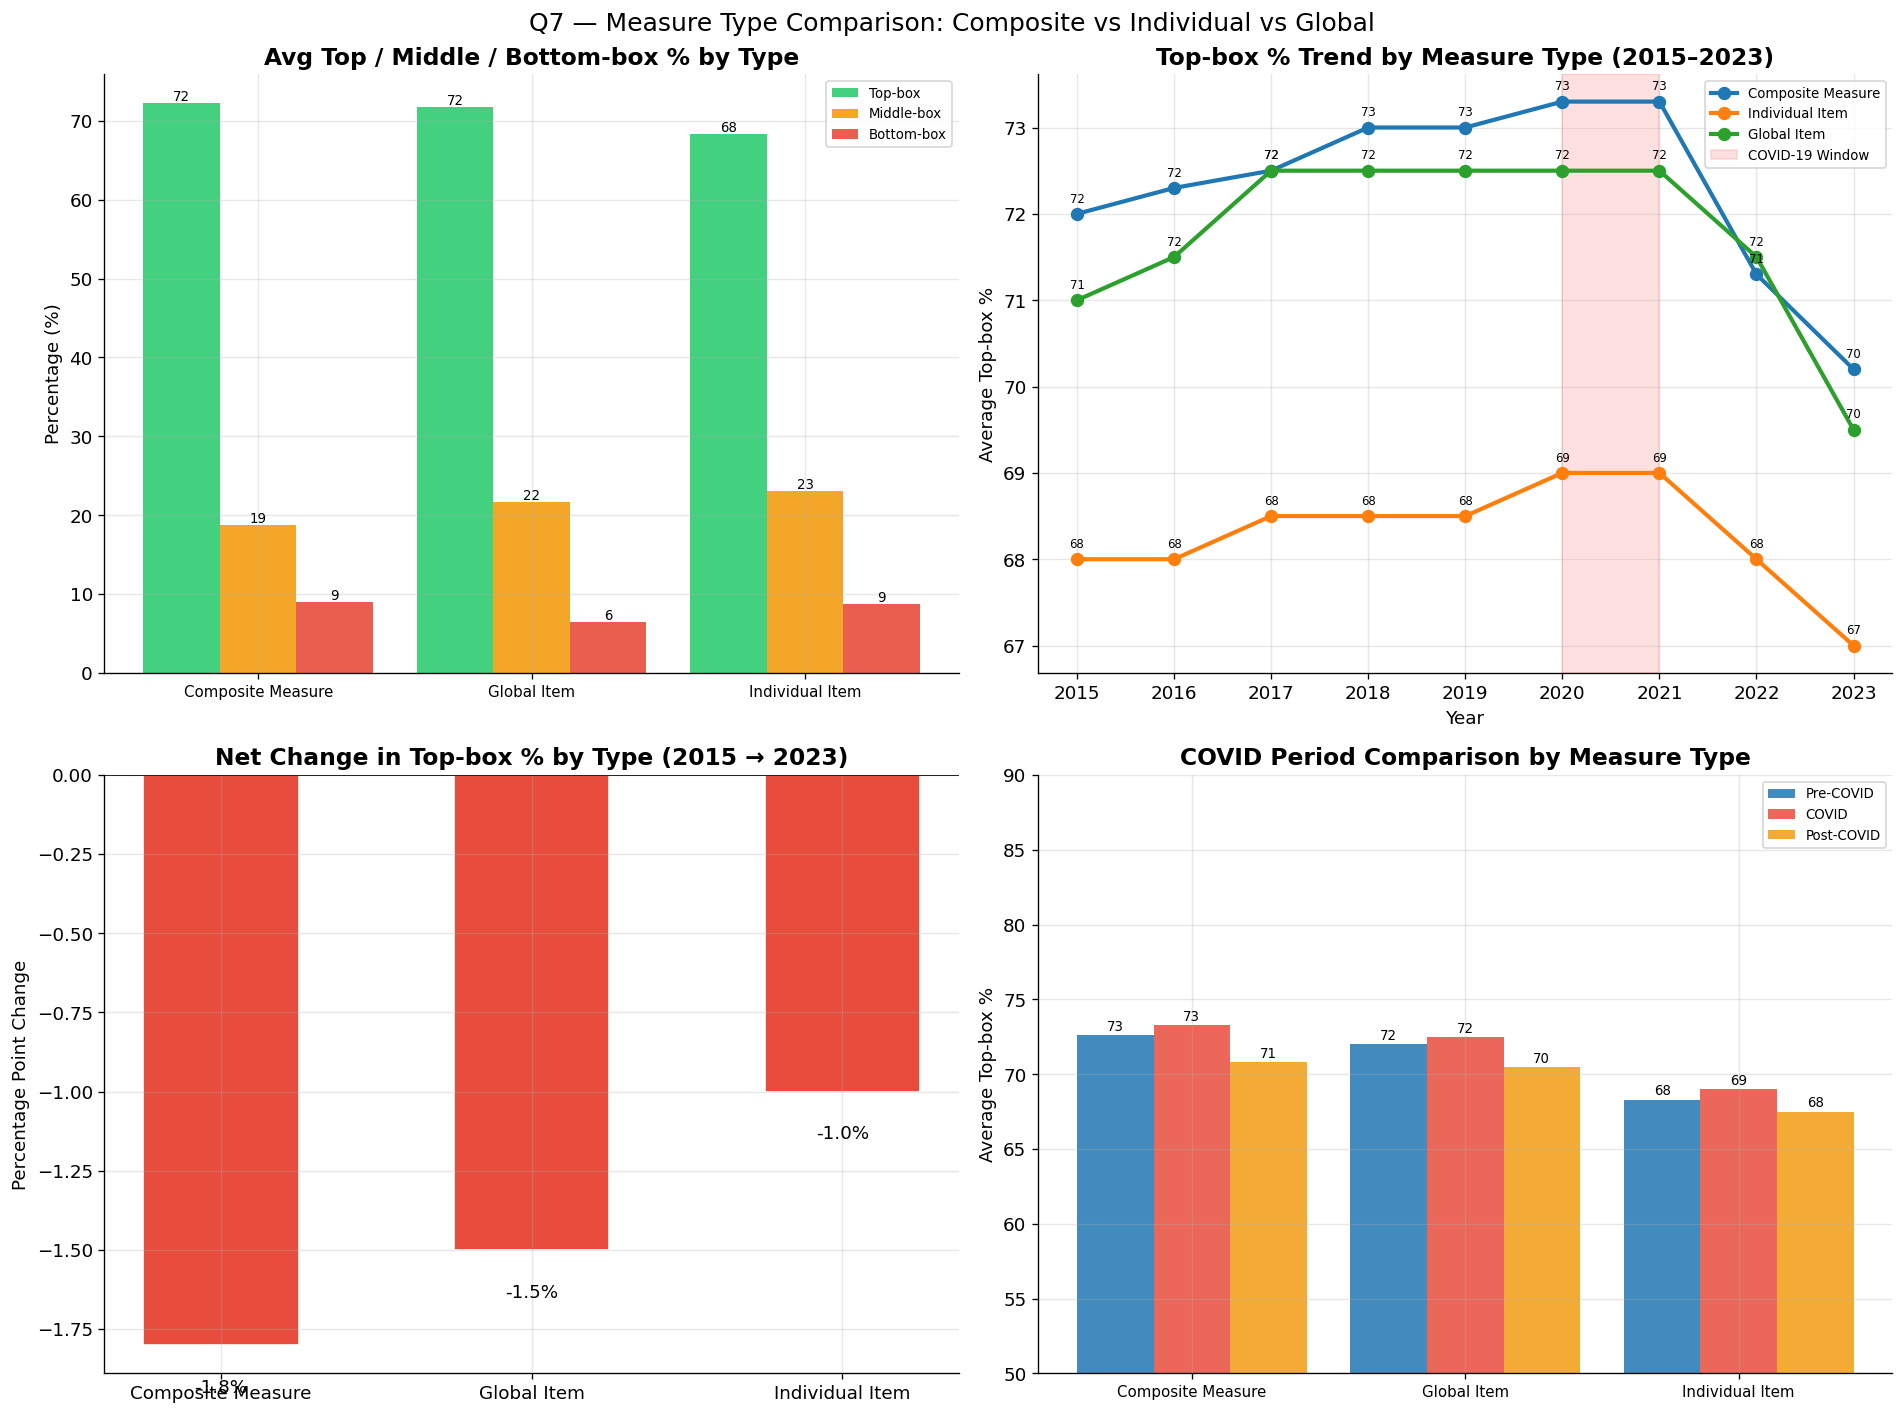

💾 Chart saved → /home/pharmacy/HCAHPS+Patient+Survey/Charts/08_Q7_Measure_Type_Comparison.png


In [13]:
# ============================================================
# Q7 — MEASURE TYPE COMPARISON
# ============================================================

# ── 1. Average Top-box % by type across all years ────────────
type_avg = (national_df
            .groupby('Type')[['Top_pct', 'Bottom_pct', 'Middle_pct']]
            .mean()
            .round(1)
            .sort_values('Top_pct', ascending=False))

print("📊 Average Scores by Measure Type (All Years)")
print("─"*55)
display(type_avg)
print()

# ── 2. Type trend over time ───────────────────────────────────
type_trend = (national_df
              .groupby(['Type', 'Year'])['Top_pct']
              .mean()
              .round(1)
              .reset_index())

# ── 3. Net change by type ────────────────────────────────────
type_net = {}
for t in type_trend['Type'].unique():
    data  = type_trend[type_trend['Type'] == t].set_index('Year')
    start = data.loc[2015, 'Top_pct']
    end   = data.loc[2023, 'Top_pct']
    peak  = data['Top_pct'].max()
    peak_y= data['Top_pct'].idxmax()
    type_net[t] = {
        'Start (2015)': start,
        'End (2023)'  : end,
        'Peak %'      : peak,
        'Peak Year'   : peak_y,
        'Net Change'  : round(end - start, 1),
        'Post-Peak Drop': round(end - peak, 1),
    }

type_net_df = pd.DataFrame(type_net).T
print("📈 Net Change by Measure Type (2015 → 2023)")
print("─"*55)
display(type_net_df)
print()

# ── 4. COVID impact by type ───────────────────────────────────
type_covid = (national_df
              .groupby(['Type',
                        pd.cut(national_df['Year'],
                               bins=[2014, 2019, 2021, 2023],
                               labels=['Pre-COVID',
                                       'COVID',
                                       'Post-COVID'])])
              ['Top_pct'].mean().round(1).unstack())

print("📋 Average Top-box % by Type & Period")
print("─"*55)
display(type_covid)
print()

# ── 5. Per-measure detail within each type ───────────────────
print("🔍 Per-Measure Averages within Each Type")
print("─"*55)
for t in ['Composite Measure', 'Individual Item', 'Global Item']:
    subset = (national_df[national_df['Type'] == t]
              .groupby('Measure')['Top_pct']
              .mean().round(1)
              .sort_values(ascending=False))
    print(f"\n  [{t}]")
    for m, v in subset.items():
        print(f"    {m:<42} {v:.1f}%")
print()

# ── 6. Visualization — 2×2 dashboard ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Q7 — Measure Type Comparison: Composite vs Individual vs Global',
             fontsize=15)

TYPE_COLORS = {
    'Composite Measure': PALETTE[0],
    'Individual Item'  : PALETTE[1],
    'Global Item'      : PALETTE[2],
}

# ── 6a. Average Top/Mid/Bottom box by type ───────────────────
ax = axes[0, 0]
x     = np.arange(len(type_avg))
width = 0.28

ax.bar(x - width, type_avg['Top_pct'],
       width, label='Top-box',    color=TOP_COLOR, alpha=0.9)
ax.bar(x,         type_avg['Middle_pct'],
       width, label='Middle-box', color=MID_COLOR, alpha=0.9)
ax.bar(x + width, type_avg['Bottom_pct'],
       width, label='Bottom-box', color=BOT_COLOR, alpha=0.9)

ax.set_title('Avg Top / Middle / Bottom-box % by Type')
ax.set_ylabel('Percentage (%)')
ax.set_xticks(x)
ax.set_xticklabels(type_avg.index, fontsize=9)
ax.legend(fontsize=8)

for i, (top, mid, bot) in enumerate(zip(type_avg['Top_pct'],
                                         type_avg['Middle_pct'],
                                         type_avg['Bottom_pct'])):
    ax.text(i - width, top + 0.3, f'{top:.0f}',
            ha='center', fontsize=8)
    ax.text(i,         mid + 0.3, f'{mid:.0f}',
            ha='center', fontsize=8)
    ax.text(i + width, bot + 0.3, f'{bot:.0f}',
            ha='center', fontsize=8)

# ── 6b. Type trend over time ──────────────────────────────────
ax = axes[0, 1]
for t, color in TYPE_COLORS.items():
    data = type_trend[type_trend['Type'] == t]
    ax.plot(data['Year'], data['Top_pct'],
            marker='o', color=color, label=t, linewidth=2.5)
    for _, row in data.iterrows():
        ax.annotate(f"{row['Top_pct']:.0f}",
                    (row['Year'], row['Top_pct']),
                    textcoords='offset points',
                    xytext=(0, 7), ha='center', fontsize=7)

ax.axvspan(2020, 2021, alpha=0.12, color='red',
           label='COVID-19 Window')
ax.set_title('Top-box % Trend by Measure Type (2015–2023)')
ax.set_xlabel('Year')
ax.set_ylabel('Average Top-box %')
ax.set_xticks(type_trend['Year'].unique())
ax.legend(fontsize=8)

# ── 6c. Net change by type bar ────────────────────────────────
ax = axes[1, 0]
net_vals   = type_net_df['Net Change'].astype(float)
bar_colors = [TOP_COLOR if v >= 0 else BOT_COLOR
              for v in net_vals]
bars = ax.bar(net_vals.index, net_vals.values,
              color=bar_colors, edgecolor='white', width=0.5)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Net Change in Top-box % by Type (2015 → 2023)')
ax.set_ylabel('Percentage Point Change')

for bar, val in zip(bars, net_vals):
    offset = 0.05 if val >= 0 else -0.15
    ax.text(bar.get_x() + bar.get_width()/2,
            val + offset, f'{val:+.1f}%',
            ha='center', fontsize=11)

# ── 6d. COVID period comparison by type ──────────────────────
ax = axes[1, 1]
x2    = np.arange(len(type_covid))
width2= 0.28
period_colors = [PALETTE[0], BOT_COLOR, MID_COLOR]

for i, (period, color) in enumerate(
        zip(type_covid.columns, period_colors)):
    bars2 = ax.bar(x2 + (i - 1) * width2,
                   type_covid[period],
                   width2, label=period,
                   color=color, alpha=0.85)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{bar.get_height():.0f}',
                ha='center', fontsize=8)

ax.set_title('COVID Period Comparison by Measure Type')
ax.set_ylabel('Average Top-box %')
ax.set_xticks(x2)
ax.set_xticklabels(type_covid.index, fontsize=9)
ax.set_ylim(50, 90)
ax.legend(fontsize=8)

plt.tight_layout()
chart_path = os.path.join(CHARTS_DIR, '08_Q7_Measure_Type_Comparison.png')
plt.savefig(chart_path, bbox_inches='tight')
plt.show()
print(f"💾 Chart saved → {chart_path}")

## 11. Final Recommendations & Conclusions

### Summary of Key Findings

| # | Finding | Severity |
|---|---------|----------|
| 1 | Overall scores declined -1.6% from 2015→2023 | 🔴 High |
| 2 | All 10 measures declined or held flat — zero net improvement | 🔴 High |
| 3 | Care Transition chronically lowest at 52.6% avg (-18.8pp below national avg) | 🔴 Critical |
| 4 | Communication about Medicines: highest Bottom-box burden (17-20%) & worst net decline (-4%) | 🔴 Critical |
| 5 | Post-COVID collapse (-2.3%) erased all gains made 2015→2021 | 🔴 High |
| 6 | Response rates fell from 30.8%→22.7% — growing non-response bias risk | 🟡 Medium |
| 7 | Mid-Atlantic region consistently underperforms (-4pp vs average) | 🟡 Medium |
| 8 | Midwest states (SD, NE, KS) outperform by +5pp — benchmarking opportunity | 🟢 Opportunity |
| 9 | r=0.593 correlation between response rate and scores — engagement matters | 🟡 Medium |

---

### Data-Driven Recommendations

#### 🔴 Priority 1 — Redesign Care Transition Processes
Care Transition has been stuck at 50–54% for 9 consecutive years.
This is not a COVID effect — it is a **structural failure**.
Hospitals should implement dedicated discharge planning teams,
standardized medication reconciliation, and post-discharge
follow-up calls within 48 hours.

#### 🔴 Priority 2 — Improve Medicine Communication Protocols
With a Bottom-box rate reaching 20% in 2023, 1 in 5 patients
report the worst possible experience with medicine communication.
Hospitals should mandate bedside pharmacist consultations,
use plain-language medication cards, and require teach-back
confirmation before discharge.

#### 🔴 Priority 3 — Address Post-COVID Staff Burnout
The sharp post-2021 decline across all measures aligns with
documented healthcare worker burnout. Hospitals should invest
in staff mental health programs, safe staffing ratios, and
communication skills training to restore pre-COVID service levels.

#### 🟡 Priority 4 — Target Responsiveness of Hospital Staff
Declining from 68%→65% with a -5pp post-peak drop, responsiveness
reflects staffing levels and call-light protocols. Hospitals should
audit response time benchmarks and implement accountability systems.

#### 🟡 Priority 5 — Learn from High-Performing States
South Dakota, Nebraska, and Kansas consistently outperform by
4–5 percentage points. CMS and hospital systems should commission
best-practice studies in these states to identify transferable
operational models for lower-performing peers.

#### 🟢 Priority 6 — Invest in Survey Participation
With response rates at 22.7% and a correlation of r=0.593
between participation and scores, improving survey engagement
is itself a quality indicator. Hospitals should implement
post-discharge SMS/email surveys and multilingual outreach
to improve representativeness.

---

### Conclusion
HCAHPS data tells a clear and urgent story: **American hospitals
are not improving patient experience — they are losing ground**.
The post-COVID period has accelerated a decline that was already
underway. Targeted interventions in Care Transition, Medicine
Communication, and Staff Responsiveness — modeled on
high-performing Midwest states — offer the clearest path
toward measurable improvement.

---
*Analysis completed | Python · Pandas · Matplotlib · Seaborn*
*Data: HCAHPS National Patient Survey 2015–2023*

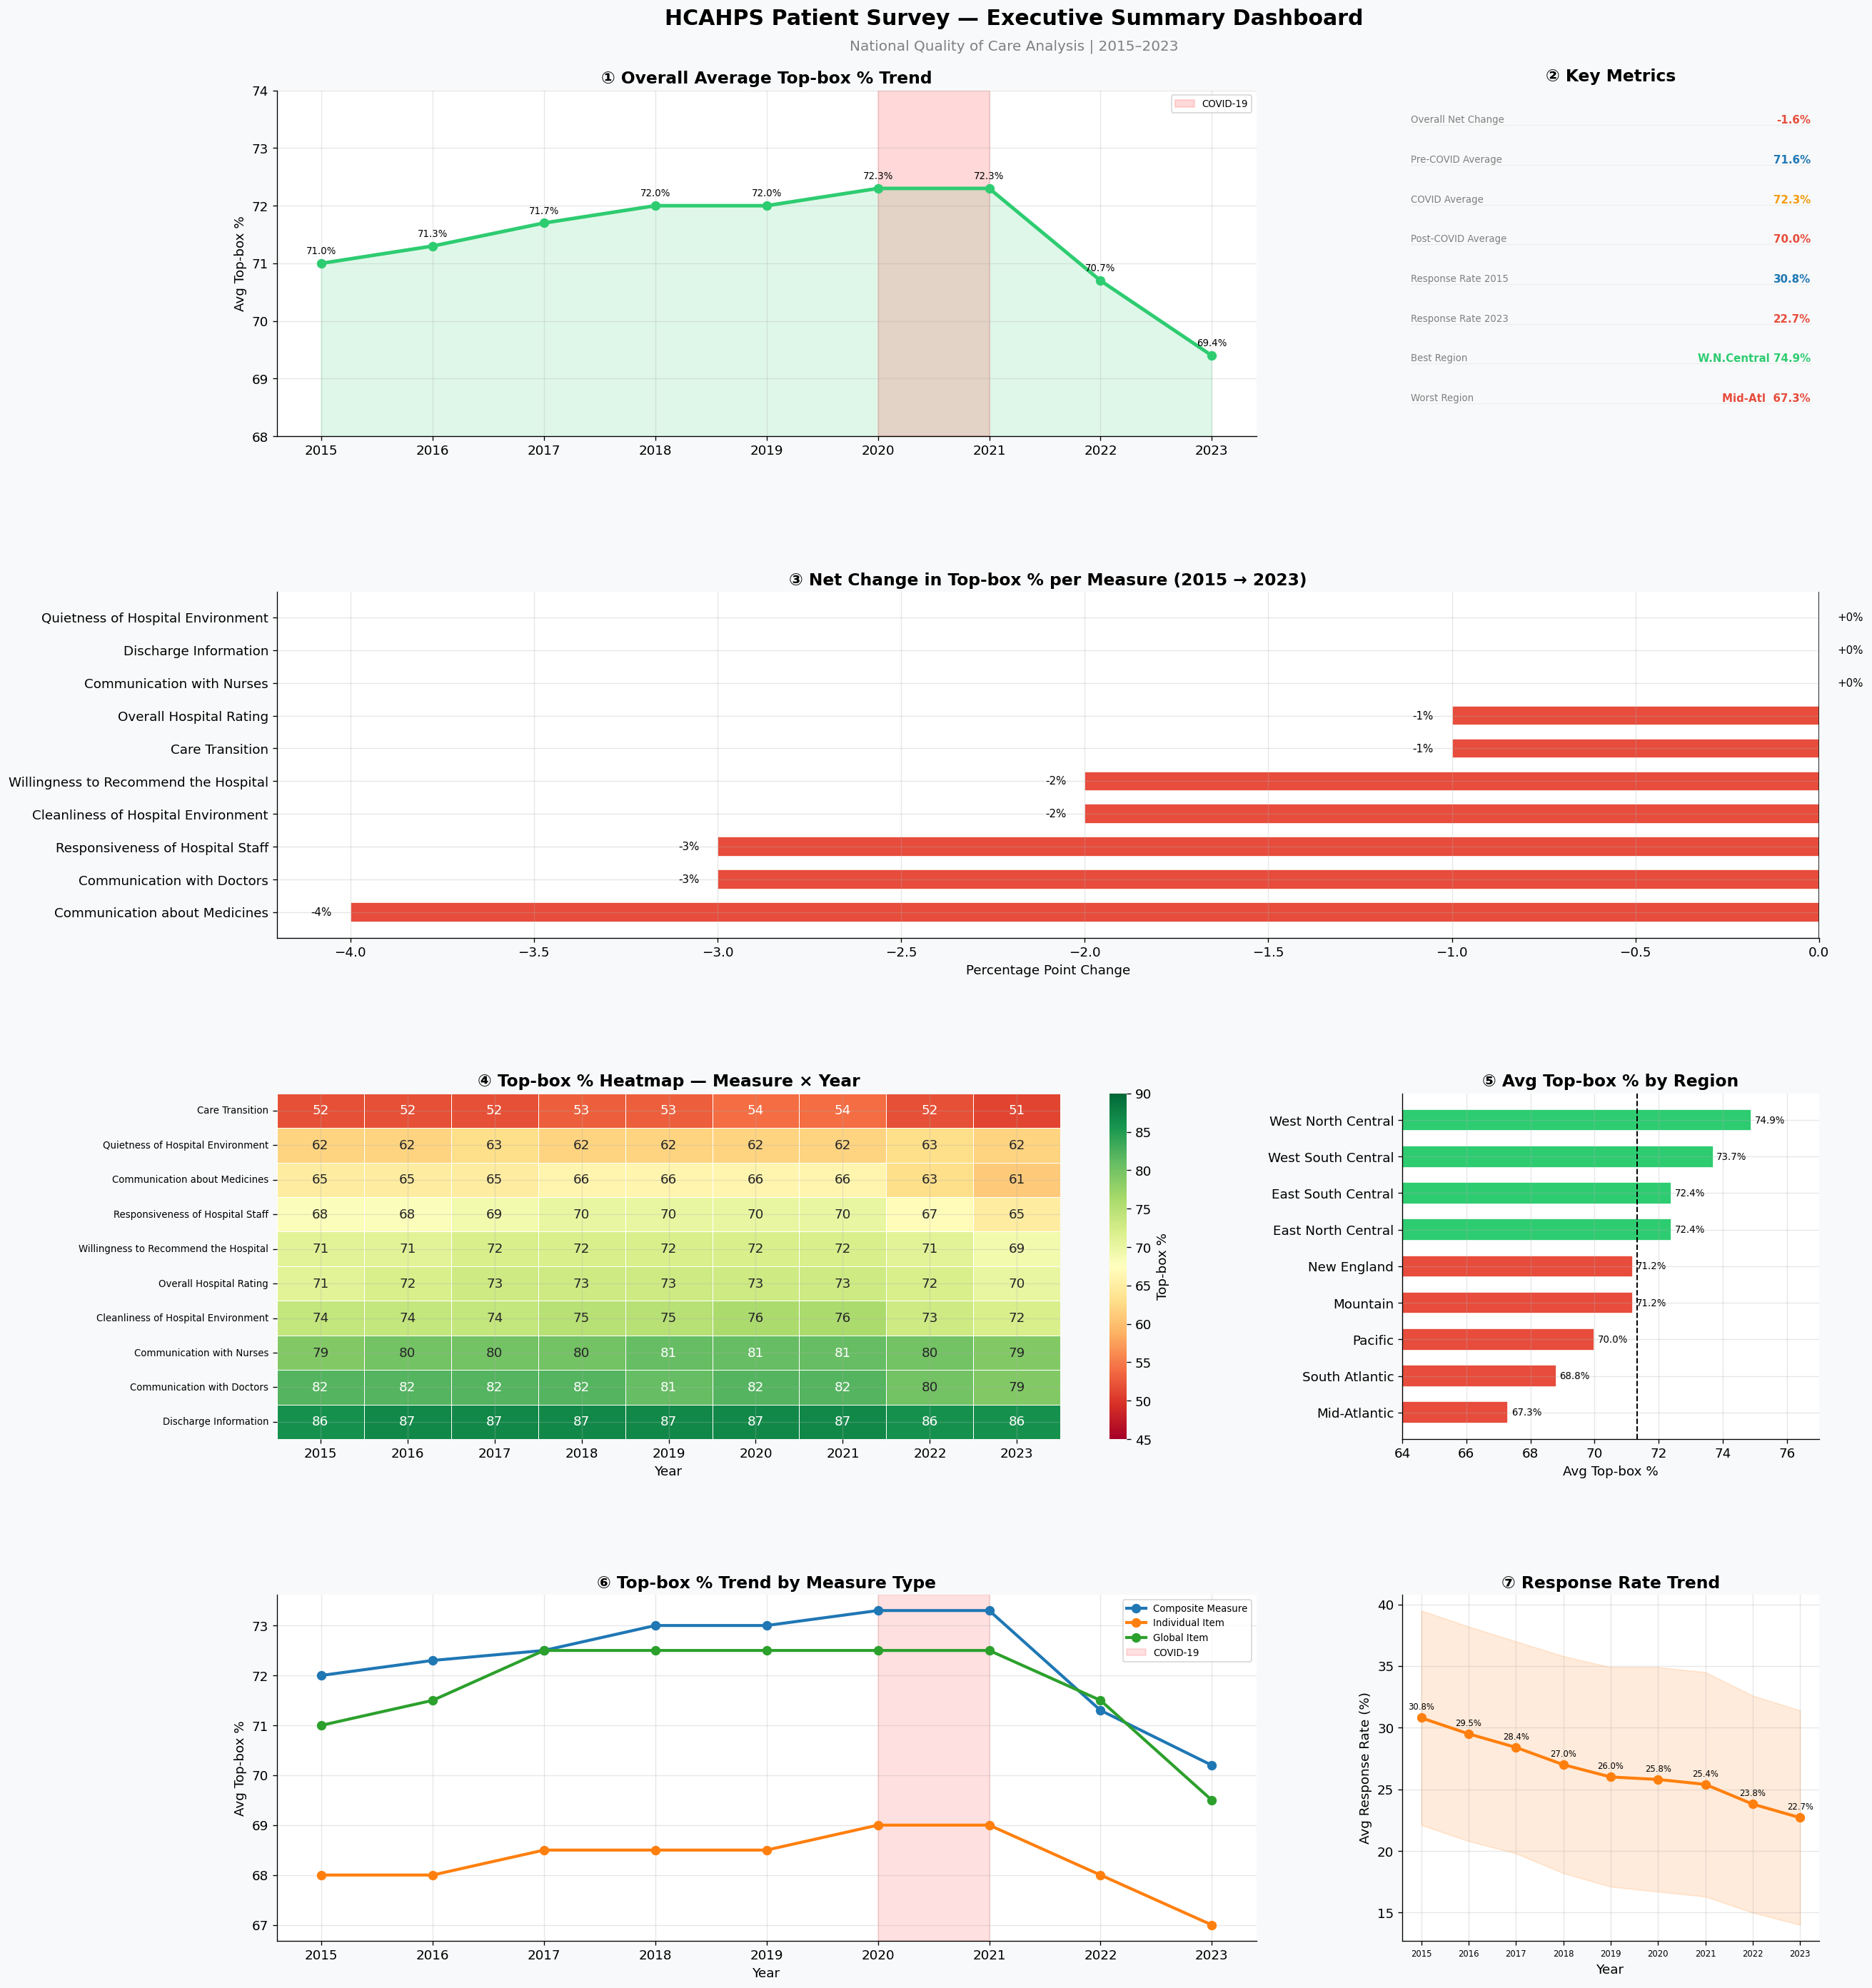

💾 Dashboard saved → /home/pharmacy/HCAHPS+Patient+Survey/Charts/09_Final_Summary_Dashboard.png

✅ HCAHPS Analysis Notebook — COMPLETE
   Charts saved to : /home/pharmacy/HCAHPS+Patient+Survey/Charts
   Total charts    : 9
   Total cells     : 24


In [16]:
# ============================================================
# FINAL SUMMARY DASHBOARD
# ============================================================

fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor('#f8f9fa')

# Title
fig.text(0.5, 0.98,
         'HCAHPS Patient Survey — Executive Summary Dashboard',
         ha='center', va='top', fontsize=18, fontweight='bold')
fig.text(0.5, 0.965,
         'National Quality of Care Analysis | 2015–2023',
         ha='center', va='top', fontsize=12, color='gray')

# ── Grid layout ───────────────────────────────────────────────
gs = fig.add_gridspec(4, 3,
                      hspace=0.45, wspace=0.35,
                      top=0.94, bottom=0.04,
                      left=0.07, right=0.97)

# ── Panel 1 — Overall trend ───────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
avg_trend = national_df.groupby('Year')['Top_pct'].mean()
ax1.fill_between(avg_trend.index, avg_trend.values,
                 alpha=0.15, color=TOP_COLOR)
ax1.plot(avg_trend.index, avg_trend.values,
         marker='o', color=TOP_COLOR, linewidth=3)
ax1.axvspan(2020, 2021, alpha=0.15, color='red',
            label='COVID-19')
for x, y in zip(avg_trend.index, avg_trend.values):
    ax1.annotate(f'{y:.1f}%', (x, y),
                 textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=8)
ax1.set_title('① Overall Average Top-box % Trend', fontweight='bold')
ax1.set_ylabel('Avg Top-box %')
ax1.set_xticks(avg_trend.index)
ax1.set_ylim(68, 74)
ax1.legend(fontsize=8)
ax1.set_facecolor('#ffffff')

# ── Panel 2 — KPI cards ───────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis('off')
ax2.set_facecolor('#ffffff')
kpis = [
    ('Overall Net Change',     '-1.6%',  BOT_COLOR),
    ('Pre-COVID Average',      '71.6%',  PALETTE[0]),
    ('COVID Average',          '72.3%',  MID_COLOR),
    ('Post-COVID Average',     '70.0%',  BOT_COLOR),
    ('Response Rate 2015',     '30.8%',  PALETTE[0]),
    ('Response Rate 2023',     '22.7%',  BOT_COLOR),
    ('Best Region',  'W.N.Central 74.9%', TOP_COLOR),
    ('Worst Region', 'Mid-Atl  67.3%',   BOT_COLOR),
]
ax2.set_title('② Key Metrics', fontweight='bold', pad=8)
for i, (label, val, color) in enumerate(kpis):
    y = 0.93 - i * 0.115
    ax2.text(0.02, y, label,
             transform=ax2.transAxes,
             fontsize=8, color='gray', va='top')
    ax2.text(0.98, y, val,
             transform=ax2.transAxes,
             fontsize=9, color=color,
             fontweight='bold', va='top', ha='right')
    # separator line using axes coordinates
    ax2.plot([0.02, 0.98],
             [y - 0.03, y - 0.03],
             transform=ax2.transAxes,
             color='#eeeeee', linewidth=0.8,
             clip_on=False)

# ── Panel 3 — Net change per measure ─────────────────────────
ax3 = fig.add_subplot(gs[1, :])
net_sorted = summary_df.sort_values('Net Change')
colors3    = [TOP_COLOR if v >= 0 else BOT_COLOR
              for v in net_sorted['Net Change']]
bars3 = ax3.barh(net_sorted['Measure'],
                 net_sorted['Net Change'],
                 color=colors3, edgecolor='white', height=0.6)
ax3.axvline(0, color='black', linewidth=1)
ax3.set_title('③ Net Change in Top-box % per Measure (2015 → 2023)',
              fontweight='bold')
ax3.set_xlabel('Percentage Point Change')
ax3.set_facecolor('#ffffff')
for bar, val in zip(bars3, net_sorted['Net Change']):
    offset = 0.05 if val >= 0 else -0.05
    ha     = 'left' if val >= 0 else 'right'
    ax3.text(val + offset,
             bar.get_y() + bar.get_height()/2,
             f'{val:+.0f}%', va='center', ha=ha, fontsize=9)

# ── Panel 4 — Opportunity heatmap ────────────────────────────
ax4 = fig.add_subplot(gs[2, :2])
sns.heatmap(heatmap_top,
            annot=True, fmt='.0f',
            cmap='RdYlGn',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Top-box %'},
            ax=ax4, vmin=45, vmax=90)
ax4.set_title('④ Top-box % Heatmap — Measure × Year',
              fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('')
ax4.tick_params(axis='y', labelsize=8)

# ── Panel 5 — Regional ranking ───────────────────────────────
ax5 = fig.add_subplot(gs[2, 2])
region_sorted = region_avg.sort_values()
nat_avg2      = region_avg.mean()
colors5       = [TOP_COLOR if v >= nat_avg2 else BOT_COLOR
                 for v in region_sorted.values]
ax5.barh(region_sorted.index,
         region_sorted.values,
         color=colors5, edgecolor='white', height=0.6)
ax5.axvline(nat_avg2, color='black',
            linestyle='--', linewidth=1.2)
ax5.set_title('⑤ Avg Top-box % by Region',
              fontweight='bold')
ax5.set_xlabel('Avg Top-box %')
ax5.set_xlim(64, 77)
ax5.set_facecolor('#ffffff')
for i, (val, label) in enumerate(
        zip(region_sorted.values, region_sorted.index)):
    ax5.text(val + 0.1, i, f'{val:.1f}%',
             va='center', fontsize=8)

# ── Panel 6 — Type trend ──────────────────────────────────────
ax6 = fig.add_subplot(gs[3, :2])
for t, color in TYPE_COLORS.items():
    data = type_trend[type_trend['Type'] == t]
    ax6.plot(data['Year'], data['Top_pct'],
             marker='o', color=color,
             label=t, linewidth=2.5)
ax6.axvspan(2020, 2021, alpha=0.12, color='red',
            label='COVID-19')
ax6.set_title('⑥ Top-box % Trend by Measure Type',
              fontweight='bold')
ax6.set_xlabel('Year')
ax6.set_ylabel('Avg Top-box %')
ax6.set_xticks(type_trend['Year'].unique())
ax6.legend(fontsize=8)
ax6.set_facecolor('#ffffff')

# ── Panel 7 — Response rate trend ────────────────────────────
ax7 = fig.add_subplot(gs[3, 2])
ax7.plot(rr_national.index, rr_national['Mean RR'],
         marker='o', color=PALETTE[1], linewidth=2.5)
ax7.fill_between(rr_national.index,
                 rr_national['Mean RR'] - rr_national['Std Dev'],
                 rr_national['Mean RR'] + rr_national['Std Dev'],
                 alpha=0.15, color=PALETTE[1])
for x, y in zip(rr_national.index, rr_national['Mean RR']):
    ax7.annotate(f'{y:.1f}%', (x, y),
                 textcoords='offset points',
                 xytext=(0, 7), ha='center', fontsize=7)
ax7.set_title('⑦ Response Rate Trend',
              fontweight='bold')
ax7.set_xlabel('Year')
ax7.set_ylabel('Avg Response Rate (%)')
ax7.set_xticks(rr_national.index)
ax7.tick_params(axis='x', labelsize=7)
ax7.set_facecolor('#ffffff')

# ── Save ──────────────────────────────────────────────────────
chart_path = os.path.join(CHARTS_DIR,
                          '09_Final_Summary_Dashboard.png')
plt.savefig(chart_path, bbox_inches='tight',
            facecolor=fig.get_facecolor(), dpi=150)
plt.show()
print(f"💾 Dashboard saved → {chart_path}")
print()
print("="*55)
print("✅ HCAHPS Analysis Notebook — COMPLETE")
print("="*55)
print(f"   Charts saved to : {CHARTS_DIR}")
print(f"   Total charts    : 9")
print(f"   Total cells     : 24")
print("="*55)

=======================================
# Thank you
=======================================